# Download Dataset

In [ ]:
import os
import re
import requests
from urllib.parse import unquote

def download_gdrive(links, dest_folder="/content"):
    """
    Download files from Google Drive (supports single link or list).
    Preserves original filename.
    """
    if isinstance(links, str):
        links = [links] # Convert to list if single link

    os.makedirs(dest_folder, exist_ok=True)
    session = requests.Session()
    saved_files = []

    # Standard API URL for download
    url = "https://drive.google.com/uc?export=download"

    for link in links:
        try:
            # 1. Extract File ID using Regex
            match = re.search(r'[?&]id=([a-zA-Z0-9_-]+)|/d/([a-zA-Z0-9_-]+)', link)
            fid = match.group(1) or match.group(2) if match else None

            if not fid:
                print(f"⚠️ ID not found in link: {link}")
                continue

            params = {'id': fid}

            # 2. Send initial request
            response = session.get(url, params=params, stream=True)

            # 3. Handle confirmation token (for large files > 100MB)
            token = None
            for key, value in response.cookies.items():
                if key.startswith('download_warning'):
                    token = value
                    break

            if token:
                params['confirm'] = token
                response = session.get(url, params=params, stream=True)

            # 4. Extract filename from Header
            content_disposition = response.headers.get('content-disposition', '')
            fname_match = re.findall(r'filename\*?=([^;]+)', content_disposition)

            if fname_match:
                # Clean filename, remove 'UTF-8''' and decode special chars
                filename = fname_match[0].strip().replace('"', '').replace("'", "")
                if "UTF-8" in filename:
                    filename = filename.split("''")[-1]
                filename = unquote(filename)
            else:
                filename = f"{fid}.file" # Fallback if name not found

            # 5. Save file
            out_path = os.path.join(dest_folder, filename)
            with open(out_path, "wb") as f:
                for chunk in response.iter_content(32768):
                    if chunk: f.write(chunk)

            print(f"✅ Downloaded: {filename}")
            saved_files.append(out_path)

        except Exception as e:
            print(f"❌ Error downloading {link}: {str(e)}")

    return saved_files

# --- EXECUTE DOWNLOAD ---
list_urls = [
    "https://drive.google.com/file/d/10jDaXgE7TFotI-LyLX0ONn1LewdCZsJb/view?usp=sharing", # final_dataset_v3_preprocessed.csv
    "https://drive.google.com/file/d/1UG4pmrXXcmpfYo4ORrwXMHbVLYux44dA/view?usp=sharing"  # vietnamese-stopwords.txt
]

saved_paths = download_gdrive(list_urls, "/content/")
print("Saved files list:", saved_paths)

✅ Downloaded: final_dataset_v3.csv
✅ Downloaded: stopwords.txt
Saved files list: ['/content/final_dataset_v3.csv', '/content/stopwords.txt']


# Preprocessing Data

In [3]:
!pip -q install py_vncorenlp gensim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 16.8 MB/s eta 0:00:00


In [ ]:
# ==============================================================================
# CELL 1: SETUP VNCORENLP (JAVA & MODEL)
# ==============================================================================
import os, subprocess
from pathlib import Path

# --- CONFIGURATION ---
SAVE_DIR = "/content/vncorenlp"
JAVA_HEAP = "-Xmx4g"
ANNOTATORS = ["wseg", "pos", "ner"]  # Word Segmentation, POS Tagging, Named Entity Recognition
os.makedirs(SAVE_DIR, exist_ok=True)

# --- UTILITY FUNCTION ---
def run_shell(cmd):
    print("> " + cmd)
    res = subprocess.run(cmd, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    return res.returncode, res.stdout.strip(), res.stderr.strip()

# ==============================================================================
# 1. CHECK & INSTALL JAVA (REQUIRED FOR VNCORENLP)
# ==============================================================================
rc, out, err = run_shell("which javac || true")
if not out:
    print("Installing OpenJDK...")
    run_shell("apt-get update -qq")
    run_shell("apt-get install -y openjdk-11-jdk-headless -qq")
    print("OpenJDK installed")
else:
    print("javac found at:", out)

# ==============================================================================
# 2. CHECK & DOWNLOAD VNCORENLP MODEL
# ==============================================================================
p = Path(SAVE_DIR)
if not any(p.glob("VnCoreNLP-*.jar")):
    print("VnCoreNLP jar not found — attempting download via py_vncorenlp.download_model()")
    try:
        from py_vncorenlp import download_model
        download_model(save_dir=SAVE_DIR)
        print("Model downloaded to", SAVE_DIR)
    except Exception as e:
        print("Automatic download failed:", e)
        print("Please place VnCoreNLP jar and models into", SAVE_DIR)
else:
    print("VnCoreNLP jar already present in", SAVE_DIR)

# ==============================================================================
# 3. START SERVER & REGISTER GLOBAL OBJECT
# ==============================================================================
# Start VnCoreNLP server and expose as globals()['model']
model = globals().get("model", None)
if model is None:
    try:
        from py_vncorenlp import VnCoreNLP
        print("Starting VnCoreNLP from", SAVE_DIR, "with heap", JAVA_HEAP, "and annotators", ANNOTATORS)
        model = VnCoreNLP(save_dir=SAVE_DIR, annotators=ANNOTATORS, max_heap_size=JAVA_HEAP)
        globals()['model'] = model
        print("VnCoreNLP started and stored as globals()['model']")
    except Exception as e:
        print("Failed to start VnCoreNLP:", e)
        raise
else:
    print("Reusing existing globals()['model']")

# ==============================================================================
# 4. VERIFICATION DEMO
# ==============================================================================
print("\n--- Demo annotation ---")
demo_text = "Ông Nguyễn Khắc Chúc đang làm việc tại Đại học Quốc gia Hà Nội. Bà Lan, vợ ông Chúc, cũng làm việc tại đây."
ann = model.annotate_text(demo_text)
try:
    model.print_out(ann)
except Exception:
    print(ann)

> which javac || true
javac found at: /usr/bin/javac
VnCoreNLP jar not found — attempting download via py_vncorenlp.download_model()
Model downloaded to /content/vncorenlp
Starting VnCoreNLP from /content/vncorenlp with heap -Xmx4g and annotators ['wseg', 'pos', 'ner']
VnCoreNLP started and stored as globals()['model']

--- Demo annotation ---
1	Ông	Nc	O	_	_
2	Nguyễn_Khắc_Chúc	Np	B-PER	_	_
3	đang	R	O	_	_
4	làm_việc	V	O	_	_
5	tại	E	O	_	_
6	Đại_học	N	B-ORG	_	_
7	Quốc_gia	N	I-ORG	_	_
8	Hà_Nội	Np	I-ORG	_	_
9	.	CH	O	_	_

1	Bà	Nc	O	_	_
2	Lan	Np	B-PER	_	_
3	,	CH	O	_	_
4	vợ	N	O	_	_
5	ông	Nc	O	_	_
6	Chúc	Np	B-PER	_	_
7	,	CH	O	_	_
8	cũng	R	O	_	_
9	làm_việc	V	O	_	_
10	tại	E	O	_	_
11	đây	P	O	_	_
12	.	CH	O	_	_



In [ ]:
# ==============================================================================
# CELL 2: PREPROCESSING PIPELINE (CLEAN, TOKENIZE, POS/NER, PHRASE DETECTION)
# ==============================================================================
import os
import re
import json
import unicodedata
import pandas as pd
from tqdm.auto import tqdm
from collections import Counter, defaultdict
from typing import List, Tuple

# Gensim
from gensim.models import Phrases
from gensim.models.phrases import Phraser

# ==============================================================================
# 1. CONFIGURATION & MODEL CHECK
# ==============================================================================
# --- CHECK MODEL FROM CELL 1 ---
model = globals().get("model")

# --- FILE PATHS ---
INPUT_CSV           = "/content/final_dataset_v3.csv"
OUTPUT_CSV          = "/content/final_dataset_v3_preprocessed.csv"
STOPWORDS_TXT       = "/content/stopwords.txt"

# --- PROCESSING PARAMETERS ---
CHUNKSIZE           = 2000
SAMPLE_MODE         = False
N_SAMPLE            = 2000
DEBUG_SAMPLES       = 3

# --- VOCABULARY FILTERING ---
MIN_DOC_FREQ        = 20
MAX_DOC_FREQ_RATIO  = 0.7
MIN_TOKENS_PER_SONG = 5

# --- LOGIC CONFIG (POS & NER) ---
VALID_POS_PREFIX    = ("N", "V", "A")
INVALID_POS_PREFIX  = ("Nc", "Nu", "M", "R", "L", "E", "C", "I", "P", "T")
VALID_NER_TAGS      = {"B-LOC", "I-LOC", "B-ORG", "I-ORG"}

# --- GENSIM PHRASES CONFIG ---
PHRASES_MIN_COUNT   = 15
PHRASES_THRESHOLD   = 100

# ==============================================================================
# 2. UTILITY FUNCTIONS
# ==============================================================================

def clean_lyrics_smart(text: str) -> str:
    """Aggressive cleaning: REMOVE NUMBERS, PUNCTUATION."""
    if not text or not isinstance(text, str): return ""

    t = unicodedata.normalize("NFKC", text)

    # Remove URL, Email, HTML, Content in brackets
    t = re.sub(r'https?://\S+|www\.\S+', ' ', t)
    t = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', t)
    t = re.sub(r'<[^>]+>', ' ', t)
    t = re.sub(r'\[.*?\]|\(.*?\)', ' ', t)

    # Keep only Letters, Underscore, Space, Newline
    t = re.sub(r"[^A-Za-zÀ-ỹà-ỹ_\s\n]", ' ', t)

    # Handle whitespace
    t = re.sub(r'[ \t]+', ' ', t)
    t = re.sub(r'\n\s+', '\n', t)
    t = re.sub(r'\s+\n', '\n', t)

    return t.strip()

def split_text_smart(text, max_len=100):
    """Split text into smaller chunks by newline (\n)"""
    lines = text.split('\n')
    chunks = []
    current_chunk = []

    for line in lines:
        words = line.strip().split()
        if not words: continue
        current_chunk.extend(words)
        if len(current_chunk) >= max_len:
            chunks.append(" ".join(current_chunk))
            current_chunk = []

    if current_chunk:
        chunks.append(" ".join(current_chunk))
    return chunks

def parse_vncorenlp_output(ann_result) -> List[Tuple[str, str, str]]:
    results = []

    # Helper function to extract from a token dict
    def extract_token(token):
        # Prioritize 'wordForm', fallback to 'form', else ''
        w = token.get('wordForm') or token.get('form') or ''
        p = token.get('posTag', '')
        n = token.get('nerLabel', 'O')
        return (w, p, n)

    # Case 1: Output is Dict {0: [...], 1: [...]}
    if isinstance(ann_result, dict):
        for key in ann_result:
            sent = ann_result[key]
            if isinstance(sent, list):
                for token in sent:
                    results.append(extract_token(token))

    # Case 2: Output is List [[...], [...]]
    elif isinstance(ann_result, list):
        for sent in ann_result:
            if isinstance(sent, list):
                for token in sent:
                    results.append(extract_token(token))

    return results

def apply_phrases_and_align(bigram_mod, doc_tuples):
    """Merge Grammar (VnCoreNLP) and Statistics (Gensim)"""
    if not doc_tuples: return []

    tokens = [t[0] for t in doc_tuples]
    new_tokens = bigram_mod[tokens]

    aligned = []
    old_idx = 0
    n = len(doc_tuples)

    for new_tok in new_tokens:
        if old_idx >= n: break
        curr_w, curr_p, curr_n = doc_tuples[old_idx]

        if new_tok == curr_w:
            aligned.append((new_tok, curr_p, curr_n))
            old_idx += 1
        else:
            sub_len = 0
            temp_str = ""
            matched_ner = "O"
            for k in range(old_idx, n):
                w_k, p_k, n_k = doc_tuples[k]
                temp_str = w_k if temp_str == "" else temp_str + "_" + w_k
                if n_k in VALID_NER_TAGS: matched_ner = n_k
                sub_len += 1
                if temp_str == new_tok: break

            aligned.append((new_tok, curr_p, matched_ner))
            old_idx += sub_len

    return aligned

# ==============================================================================
# 3. MAIN PIPELINE
# ==============================================================================
def run_pipeline():
    print("🚀 STARTING PROCESSING PIPELINE (FIXED PARSER)...")

    stopwords = set()
    if os.path.exists(STOPWORDS_TXT):
        with open(STOPWORDS_TXT, "r", encoding="utf-8") as f:
            stopwords = {line.strip().lower() for line in f if line.strip() and not line.startswith("#")}
        print(f"📚 Loaded {len(stopwords)} stopwords.")
    else:
        print(f"⚠️ WARNING: File {STOPWORDS_TXT} not found!")

    all_tuples_stage1 = []
    metadata_list = []

    processed_count = 0
    debug_counter_1 = 0

    reader = pd.read_csv(INPUT_CSV, dtype=str, chunksize=CHUNKSIZE)

    # ----------------------------------------------------------------------
    # STAGE 1A: CLEAN & ANNOTATE
    # ----------------------------------------------------------------------
    print("\n⏳ [Phase 1/3] Cleaning & Tokenizing...")

    for chunk in tqdm(reader, desc="Processing Chunks"):
        if SAMPLE_MODE and processed_count >= N_SAMPLE: break

        titles = chunk.get('title', ['Unknown']*len(chunk)).tolist()
        lyrics_raw = chunk.get("lyrics", "").tolist()

        texts_clean = [clean_lyrics_smart(lyr) for lyr in lyrics_raw]

        for i, txt in enumerate(texts_clean):
            if not txt.strip(): continue
            try:
                # Tokenize
                chunks = split_text_smart(txt, max_len=150)
                doc_full = []
                for sub in chunks:
                    ann = model.annotate_text(sub)
                    doc_full.extend(parse_vncorenlp_output(ann))

                if doc_full:
                    all_tuples_stage1.append(doc_full)
                    metadata_list.append(chunk.iloc[i].to_dict())

                    # DEBUG CHECK: Verify tokens
                    if debug_counter_1 < DEBUG_SAMPLES:
                        tokens_preview = [t[0] for t in doc_full[:8]]
                        print(f"\n🔍 [DEBUG] Song: {titles[i]}")
                        print(f"   ► Raw Tokens: {tokens_preview}")
                        if tokens_preview and tokens_preview[0] == "":
                             print("   ⚠️ WARNING: Empty Token! Check ann structure.")
                             # Dump structure for inspection
                             print("   ► Structure Dump:", str(ann)[:200])
                        debug_counter_1 += 1

            except Exception as e:
                pass

        processed_count += len(chunk)

    # ----------------------------------------------------------------------
    # STAGE 1B: TRAIN GENSIM PHRASES
    # ----------------------------------------------------------------------
    print("\n⏳ [Phase 2/3] Training Phrase Detection Model...")
    docs_words = [[t[0] for t in doc] for doc in all_tuples_stage1]

    if not docs_words:
        print("❌ ERROR: No data for Gensim training. Please check step 1.")
        return

    phrases = Phrases(docs_words, min_count=PHRASES_MIN_COUNT, threshold=PHRASES_THRESHOLD)
    bigram = Phraser(phrases)
    print("✅ Phrase model trained.")

    # ----------------------------------------------------------------------
    # STAGE 1C: FILTERING & EXPORT
    # ----------------------------------------------------------------------
    print("\n⏳ [Phase 3/3] Applying Filters & Saving...")

    final_rows = []
    doc_freq = Counter()
    temp_processed_docs = []
    stats_rejected = defaultdict(int)
    debug_counter_2 = 0

    for i, doc_tuples in enumerate(tqdm(all_tuples_stage1, desc="Filtering")):
        aligned_doc = apply_phrases_and_align(bigram, doc_tuples)
        clean_doc = []

        for word, pos, ner in aligned_doc:
            w_lower = word.lower()

            # Filter Logic (Checked)
            if any(char.isdigit() for char in w_lower):
                stats_rejected['number'] += 1
                continue
            if len(w_lower) < 2 and "_" not in w_lower:
                stats_rejected['short'] += 1
                continue
            if w_lower in stopwords or w_lower.replace("_", " ") in stopwords:
                stats_rejected['stopword'] += 1
                continue
            if ner in VALID_NER_TAGS:
                clean_doc.append(w_lower)
                continue
            if pos.startswith(VALID_POS_PREFIX) and not pos.startswith(INVALID_POS_PREFIX):
                clean_doc.append(w_lower)
            else:
                stats_rejected['pos'] += 1

        if debug_counter_2 < DEBUG_SAMPLES:
            title = metadata_list[i].get('title', 'Unknown')
            print(f"\n🔍 [DEBUG FINAL] Song: {title}")
            print(f"   ► Result: {clean_doc[:15]}...")
            debug_counter_2 += 1

        if clean_doc:
            temp_processed_docs.append(clean_doc)
            doc_freq.update(clean_doc)
        else:
            temp_processed_docs.append([])

    # --- FILTER BY FREQUENCY ---
    print("\n🧹 Pruning Vocabulary...")
    total_docs = len(temp_processed_docs)
    max_df_cutoff = int(total_docs * MAX_DOC_FREQ_RATIO)
    min_df_cutoff = 5 if SAMPLE_MODE else MIN_DOC_FREQ

    valid_vocab = {w for w, f in doc_freq.items() if min_df_cutoff <= f <= max_df_cutoff}
    print(f"   Vocabulary Size: {len(valid_vocab)} words")
    print(f"   Rejected Stats: {dict(stats_rejected)}")

    # --- SAVE ---
    for meta, tokens in zip(metadata_list, temp_processed_docs):
        final_tokens = [t for t in tokens if t in valid_vocab]

        if len(final_tokens) >= MIN_TOKENS_PER_SONG:
            final_rows.append({
                **meta,
                "processed_tokens": json.dumps(final_tokens, ensure_ascii=False),
                "token_count": len(final_tokens)
            })

    df_out = pd.DataFrame(final_rows)
    df_out.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

    print(f"\n🎉 COMPLETED! File saved at: {OUTPUT_CSV}")
    print(f"   Total songs after filtering: {len(df_out)}")

if __name__ == "__main__":
    run_pipeline()

🚀 STARTING PROCESSING PIPELINE (FIXED PARSER)...
📚 Loaded 3526 stopwords.

⏳ [Phase 1/3] Cleaning & Tokenizing...


Processing Chunks: 0it [00:00, ?it/s]


🔍 [DEBUG] Song: 10
   ► Raw Tokens: ['lâu_nay', 'bên', 'nhau', 'ta', 'đâu', 'giống', 'trò_chơi', 'đâu']

🔍 [DEBUG] Song: 12
   ► Raw Tokens: ['khi', 'nỗi', 'nhớ', 'vụt', 'qua', 'nơi', 'đây', 'khi']

🔍 [DEBUG] Song: 15
   ► Raw Tokens: ['Nếu', 'thẳng_thắn', 'Thì', 'nụ', 'hôn', 'sau', 'bao', 'năm']

⏳ [Phase 2/3] Training Phrase Detection Model...
✅ Phrase model trained.

⏳ [Phase 3/3] Applying Filters & Saving...


Filtering:   0%|          | 0/61525 [00:00<?, ?it/s]


🔍 [DEBUG FINAL] Song: 10
   ► Result: ['trò_chơi', 'cãi', 'quan_tâm', 'ướt', 'hoen', 'thừa', 'đau', 'dư_thừa', 'thắng', 'thắng', 'tình_yêu', 'kết_thúc', 'quan_tâm', 'ướt', 'hoen']...

🔍 [DEBUG FINAL] Song: 12
   ► Result: ['nhớ', 'vụt', 'đau_thương', 'đong_đầy', 'quên', 'tình', 'gạt', 'nước_mắt', 'nhạt_nhoà', 'tuyết', 'buông_lơi', 'đơn_côi', 'yêu_thương', 'ước_ao', 'bóng_dáng']...

🔍 [DEBUG FINAL] Song: 15
   ► Result: ['thẳng_thắn', 'hôn', 'mưa', 'tình_cờ', 'tình_yêu', 'yêu', 'thương', 'hôn', 'phi_trường', 'yêu', 'trẻ_em', 'vô_tư', 'tiếc_nuối', 'cười', 'mưa']...

🧹 Pruning Vocabulary...
   Vocabulary Size: 7884 words
   Rejected Stats: {'stopword': 8739243, 'pos': 291513, 'short': 94736}

🎉 COMPLETED! File saved at: /content/final_dataset_v3_preprocessed.csv
   Total songs after filtering: 61426


In [ ]:
# ==============================================================================
# CELL 3: CLOSE & CLEAN UP VNCORENLP
# ==============================================================================
import subprocess
import time

def close_vncorenlp():
    print("🛑 Stopping VnCoreNLP...")

    # 1. Attempt graceful shutdown via library methods
    global model
    model_ref = globals().get("model", None)

    if model_ref:
        try:
            # Check for .close() method
            if hasattr(model_ref, 'close'):
                print("   -> Calling model.close()...")
                model_ref.close()
            # Check for __exit__ method
            elif hasattr(model_ref, '__exit__'):
                print("   -> Calling model.__exit__...")
                model_ref.__exit__(None, None, None)
        except Exception as e:
            print(f"   -> Error during close: {e}")

    # 2. Delete global variable to trigger GC
    if 'model' in globals():
        del globals()['model']
        print("   -> Deleted global 'model' variable.")

    # 3. Force kill Java process (Hard kill) to release RAM
    # Since the model runs on a 4GB Java Heap, Python might close but Java remains.
    print("   -> Killing VnCoreNLP Java process...")
    try:
        cmd = "pkill -f VnCoreNLP"
        subprocess.run(cmd, shell=True)
        time.sleep(2) # Wait for system cleanup
        print("✅ Java process killed.")
    except Exception as e:
        print(f"   -> Failed to kill Java process: {e}")

    print("🎉 Resource cleanup complete!")

if __name__ == "__main__":
    close_vncorenlp()

🛑 Stopping VnCoreNLP...
   -> Deleted global 'model' variable.
   -> Killing VnCoreNLP Java process...
✅ Java process killed.
🎉 Resource cleanup complete!


--- Loading Data for Statistical Analysis ---
             DATASET STATISTICS FOR SECTION 4.1             
1. GENERAL METRICS:
   - Total Songs (Valid)    : 61,426
   - Total Tokens           : 2,533,746
   - Vocabulary Size        : 7,884
   - Avg Length (tokens)    : 41.2
   - Median Length          : 34.0
   - Max Length             : 1032

2. TEMPORAL DATA:
   - Songs with Year        : 25,356 (41.3%)
   - Songs MISSING Year     : 36,070 (58.7%)


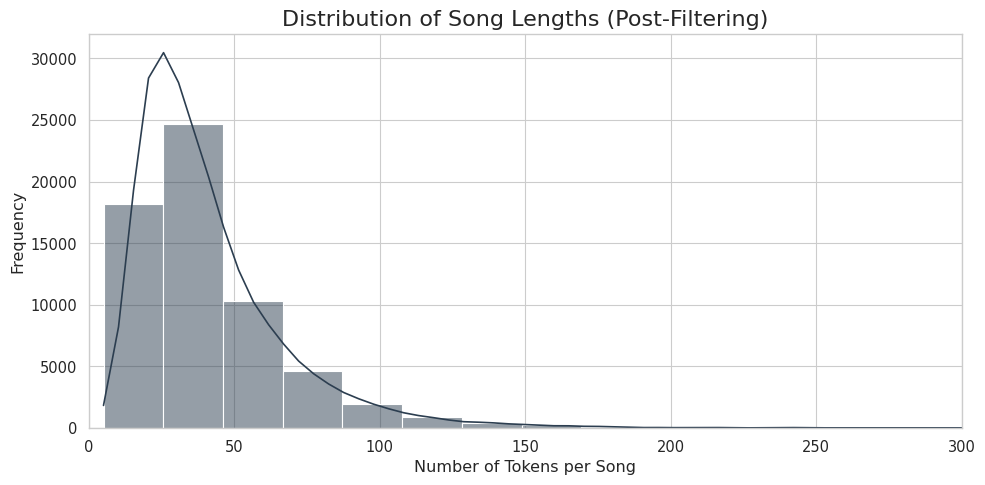

>> Figure 1 Generated: Document Length Distribution.


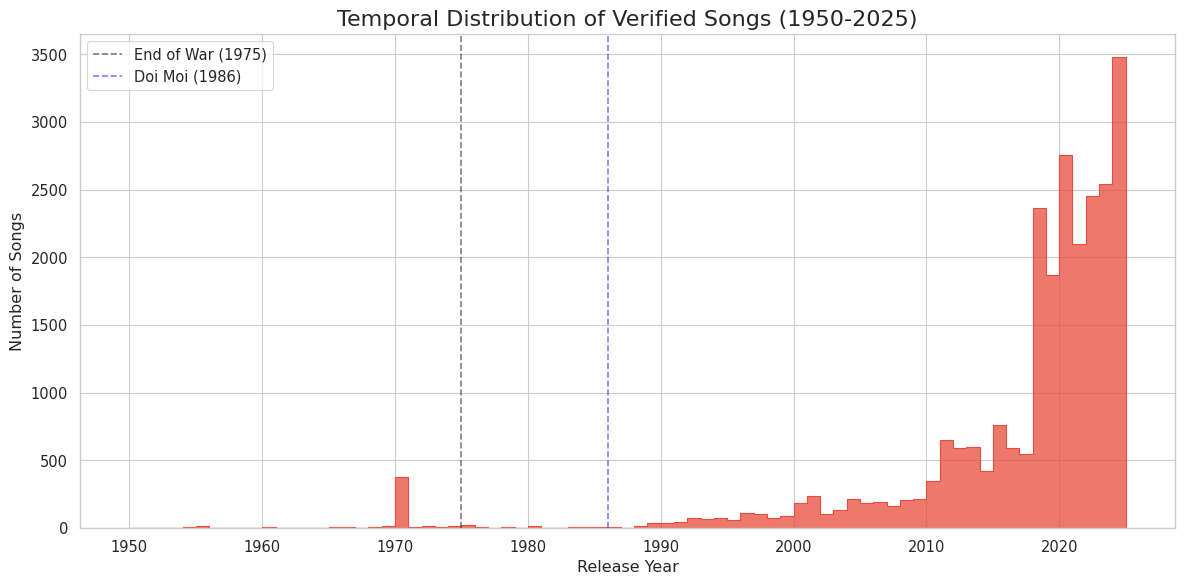

>> Figure 2 Generated: Temporal Distribution.


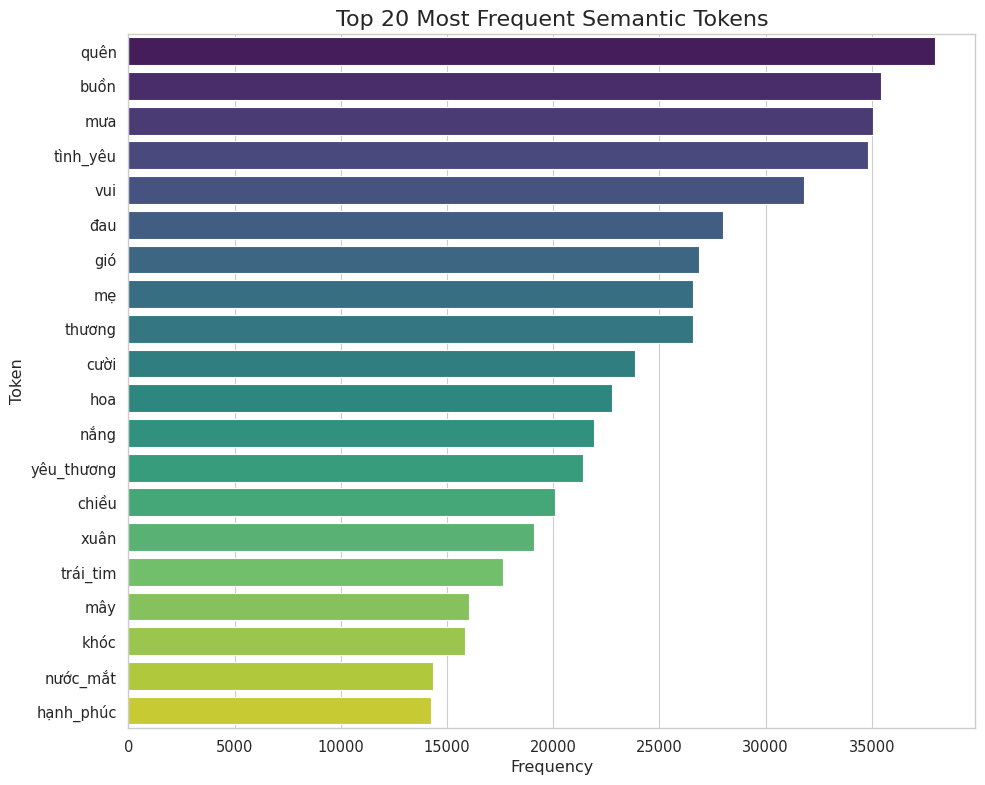

>> Figure 3 Generated: Top 20 Semantic Words.

                   QUALITATIVE INSPECTION                   
LONGEST SONGS:
                                    title  n_tokens   year
                            Minh họa Kiều      1032    NaN
Thi Ca Lịch Sử Cuộc Đời Đức Phật Thích Ca       839    NaN
                    trường ca mẹ việt nam       757    NaN
                   tổ khúc bầy chim bỏ xứ       663    NaN
                          Chỉ Vì Vật Chất       530 1970.0

SHORTEST SONGS:
                      title  n_tokens  year
123 ngôi sao 1 2 3 ngôi sao         5   NaN
                  anh ở đâu         5   NaN
           anh phải làm sao         5   NaN
             anh rất nhớ em         5   NaN
               Bé Đánh Răng         5   NaN


In [1]:
# ==============================================================================
# CELL 4: STATISTICAL ANALYSIS
# ==============================================================================
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
# Plot styling
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 16

# File paths
INPUT_CSV = "/content/final_dataset_v3_preprocessed.csv"

# ==============================================================================
# 1. LOAD DATA & PREPROCESS
# ==============================================================================
print("--- Loading Data for Statistical Analysis ---")
df = pd.read_csv(INPUT_CSV)

# Parse tokens safely
df["tokens"] = df["processed_tokens"].apply(lambda x: json.loads(x) if pd.notna(x) and x not in ("[]", "null") else [])
df["n_tokens"] = df["tokens"].apply(len)

# ==============================================================================
# 2. GENERATE STATISTICS (TABLE 4.1)
# ==============================================================================
total_songs = len(df)
total_tokens = df["n_tokens"].sum()
all_tokens_flat = [t for tokens in df["tokens"] for t in tokens]
vocab_size = len(set(all_tokens_flat))

# Analyze missing years
df['year'] = pd.to_numeric(df['year'], errors='coerce')
missing_year_count = df['year'].isna().sum()
valid_year_count = total_songs - missing_year_count
missing_ratio = (missing_year_count / total_songs) * 100

print(f"{'='*60}")
print(f"{' DATASET STATISTICS FOR SECTION 4.1 ':^60}")
print(f"{'='*60}")
print(f"1. GENERAL METRICS:")
print(f"   - Total Songs (Valid)    : {total_songs:,}")
print(f"   - Total Tokens           : {total_tokens:,}")
print(f"   - Vocabulary Size        : {vocab_size:,}")
print(f"   - Avg Length (tokens)    : {df['n_tokens'].mean():.1f}")
print(f"   - Median Length          : {df['n_tokens'].median():.1f}")
print(f"   - Max Length             : {df['n_tokens'].max()}")

print(f"\n2. TEMPORAL DATA:")
print(f"   - Songs with Year        : {valid_year_count:,} ({100-missing_ratio:.1f}%)")
print(f"   - Songs MISSING Year     : {missing_year_count:,} ({missing_ratio:.1f}%)")

# ==============================================================================
# 3. VISUALIZATION 1: DOCUMENT LENGTH DISTRIBUTION
# ==============================================================================
plt.figure(figsize=(10, 5))
sns.histplot(df['n_tokens'], bins=50, kde=True, color='#2c3e50')
plt.title('Distribution of Song Lengths (Post-Filtering)')
plt.xlabel('Number of Tokens per Song')
plt.ylabel('Frequency')
plt.xlim(0, 300) # Focus on main cluster
plt.tight_layout()
plt.show()
print(">> Figure 1 Generated: Document Length Distribution.")

# ==============================================================================
# 4. VISUALIZATION 2: TEMPORAL DISTRIBUTION
# ==============================================================================
# Filter valid years (1950-2025)
valid_years = df[(df['year'] >= 1950) & (df['year'] <= 2025)]

plt.figure(figsize=(12, 6))
sns.histplot(data=valid_years, x='year', bins=75, color='#e74c3c', element="step")
plt.title('Temporal Distribution of Verified Songs (1950-2025)')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
# Add historical markers
plt.axvline(x=1975, color='black', linestyle='--', alpha=0.5, label='End of War (1975)')
plt.axvline(x=1986, color='blue', linestyle='--', alpha=0.5, label='Doi Moi (1986)')
plt.legend()
plt.tight_layout()
plt.show()
print(">> Figure 2 Generated: Temporal Distribution.")

# ==============================================================================
# 5. VISUALIZATION 3: TOP 20 SEMANTIC WORDS
# ==============================================================================
top_20 = Counter(all_tokens_flat).most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(10, 8))
barplot = sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title('Top 20 Most Frequent Semantic Tokens')
plt.xlabel('Frequency')
plt.ylabel('Token')
plt.tight_layout()
plt.show()
print(">> Figure 3 Generated: Top 20 Semantic Words.")

# ==============================================================================
# 6. QUALITATIVE INSPECTION
# ==============================================================================
print(f"\n{'='*60}")
print(f"{' QUALITATIVE INSPECTION ':^60}")
print(f"{'='*60}")
print("LONGEST SONGS:")
print(df.nlargest(5, "n_tokens")[["title", "n_tokens", "year"]].to_string(index=False))

print("\nSHORTEST SONGS:")
print(df[df["n_tokens"]>0].nsmallest(5, "n_tokens")[["title", "n_tokens", "year"]].to_string(index=False))

# Models Trainning

## LDA Model

In [4]:
!pip -q install pyLDAvis

--- [LDA] Preparing Data & Corpus ---
   Corpus size: 61426 | Dictionary size: 5434

--- [LDA] Finding optimal K (from 6 to 30, step 2)... ---


Training LDA:   0%|          | 0/13 [00:00<?, ?it/s]

   Saved plot to: /content/stage2_LDA/lda_coherence_plot.png

🏆 BEST LDA RESULT: K=12 | Coherence=0.5646

⏳ Creating specialized visualization (/content/stage2_LDA/lda_visualization.html)...
   ✅ pyLDAvis created successfully.

--- Topic List (LDA) ---
Topic 1: thương, nghèo, hạnh_phúc, ngại, khổ, sợ, hứa, bạc, giận, đợi, tình_yêu, khó_khăn...
Topic 2: xuân, hoa, nắng, vui, gió, hương, chim, đẹp, cười, lá, tươi, mây, thơm, trăng, c...
Topic 3: mưa, tình_yêu, yêu_thương, gió, trái_tim, hôn, quên, đông, nắng, người_yêu, buồn...
Topic 4: quê, quê_hương, việt_nam, miền, làng, sông, rừng, dân, đất_nước, máu, lửa, núi, ...
Topic 5: đau, quên, tình_yêu, nước_mắt, khóc, buồn, yêu_thương, vui, trái_tim, hạnh_phúc,...
Topic 6: cười, vui, baby, thế_giới, trái_tim, đẹp, nắng, bé, love, bầu_trời, vẽ, ôm, bình...
Topic 7: sợ, học, sài_gòn, thành_phố, điên, chết, ghét, rap, bác, đông, cafe, khói, ngươi...
Topic 8: nguyện, thầy, phật, nhân_gian, trần_gian, chết, bình_an, thế_gian, đạo, lạy, cứu...
Top

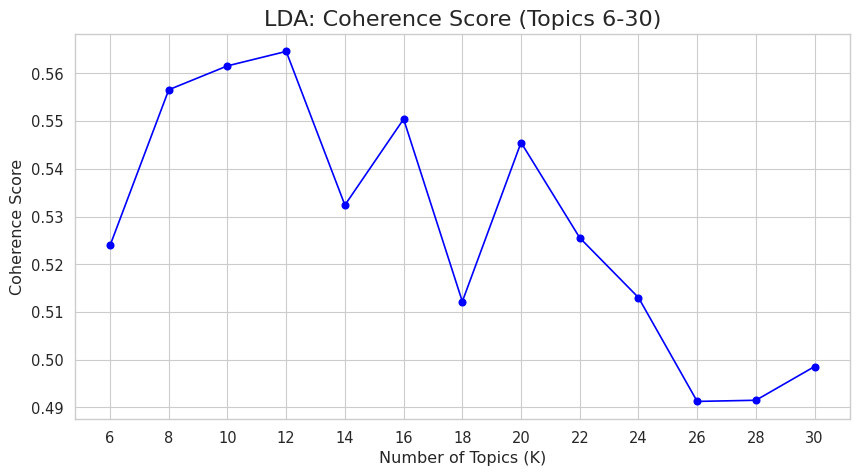

In [5]:
# ==============================================================================
# CELL 1: LDA TOPIC MODELING
# ==============================================================================
import pandas as pd
import json
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings

# Gensim & LDA
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
import pyLDAvis.gensim_models as gensimvis
import pyLDAvis

# Suppress warnings
warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
INPUT_CSV = "/content/final_dataset_v3_preprocessed.csv"
OUTPUT_DIR_LDA = "/content/stage2_LDA"
ZIP_NAME_LDA = "/content/stage2_LDA_results"

if os.path.exists(OUTPUT_DIR_LDA):
    shutil.rmtree(OUTPUT_DIR_LDA)
os.makedirs(OUTPUT_DIR_LDA, exist_ok=True)

# File paths
OUTPUT_MODEL_LDA = os.path.join(OUTPUT_DIR_LDA, "lda_model_best.gensim")
COHERENCE_PLOT_LDA = os.path.join(OUTPUT_DIR_LDA, "lda_coherence_plot.png")
HTML_VIZ_LDA = os.path.join(OUTPUT_DIR_LDA, "lda_visualization.html")

# Grid Search Parameters
START_K = 6
LIMIT_K = 31
STEP_K  = 2

# ==============================================================================
# 1. DATA PREPARATION
# ==============================================================================
print("--- [LDA] Preparing Data & Corpus ---")
if not os.path.exists(INPUT_CSV):
    print(f"❌ Error: File {INPUT_CSV} not found")
else:
    df = pd.read_csv(INPUT_CSV)
    df["tokens"] = df["processed_tokens"].apply(lambda x: json.loads(x) if isinstance(x, str) and x != "[]" else [])

    docs = df["tokens"].tolist()

    # Create Dictionary
    dictionary = corpora.Dictionary(docs)
    # Keep optimized parameters
    dictionary.filter_extremes(no_below=30, no_above=0.4)

    # Create Corpus (BoW)
    corpus = [dictionary.doc2bow(text) for text in docs]
    print(f"   Corpus size: {len(corpus)} | Dictionary size: {len(dictionary)}")

    # ==============================================================================
    # 2. FIND OPTIMAL NUMBER OF TOPICS (GRID SEARCH)
    # ==============================================================================
    print(f"\n--- [LDA] Finding optimal K (from {START_K} to {LIMIT_K-1}, step {STEP_K})... ---")

    coherence_scores = []
    model_list = []
    k_range = range(START_K, LIMIT_K, STEP_K)

    for k in tqdm(k_range, desc="Training LDA"):
        # Train LDA
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                         random_state=100, passes=10, alpha='asymmetric', eta='auto')

        # Calculate Coherence
        cm = CoherenceModel(model=model, texts=docs, dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()

        coherence_scores.append(score)
        model_list.append(model)

    # Plot Coherence Scores
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, coherence_scores, marker='o', color='blue', linestyle='-')
    plt.title(f"LDA: Coherence Score (Topics {START_K}-{LIMIT_K-1})")
    plt.xlabel("Number of Topics (K)")
    plt.ylabel("Coherence Score")
    plt.xticks(list(k_range))
    plt.grid(True)
    plt.savefig(COHERENCE_PLOT_LDA)
    print(f"   Saved plot to: {COHERENCE_PLOT_LDA}")

    # Select Best Model
    best_idx = np.argmax(coherence_scores)
    best_k_lda = list(k_range)[best_idx]
    best_lda = model_list[best_idx]
    print(f"\n🏆 BEST LDA RESULT: K={best_k_lda} | Coherence={coherence_scores[best_idx]:.4f}")

    # ==============================================================================
    # 3. CREATE VISUALIZATION (PYLDAVIS)
    # ==============================================================================
    print(f"\n⏳ Creating specialized visualization ({HTML_VIZ_LDA})...")

    # Use standard pyLDAvis for LDA
    try:
        vis = gensimvis.prepare(best_lda, corpus, dictionary, sort_topics=False)
        pyLDAvis.save_html(vis, HTML_VIZ_LDA)
        print("   ✅ pyLDAvis created successfully.")
    except Exception as e:
        print(f"   ⚠️ pyLDAvis Error: {e}")

    # ==============================================================================
    # 4. CALCULATE DIVERSITY & SAVE MODEL
    # ==============================================================================
    print("\n--- Topic List (LDA) ---")

    top_n = 25
    all_words = []

    for i in range(best_k_lda):
        words = best_lda.show_topic(i, topn=top_n)
        word_list = [w for w, _ in words]
        all_words.extend(word_list)

        topic_keywords_str = ", ".join(word_list[:20])
        print(f"Topic {i+1}: {topic_keywords_str[:80]}...")

    div = len(set(all_words)) / len(all_words) if all_words else 0
    print(f"   ► Topic Diversity Score: {div:.4f}")

    # --- SAVE MODEL ---
    print(f"⏳ Saving Model...")
    best_lda.save(OUTPUT_MODEL_LDA)

    # ==============================================================================
    # 5. ZIP RESULTS
    # ==============================================================================
    print(f"\n--- [ZIP] Compressing '{OUTPUT_DIR_LDA}'... ---")
    shutil.make_archive(ZIP_NAME_LDA, 'zip', OUTPUT_DIR_LDA)
    print(f"✅ Archive created successfully: {ZIP_NAME_LDA}.zip")

## NMF Model

--- [NMF] Preparing TF-IDF Data ---
   Created TF-IDF Corpus. Size: 61426

--- [NMF] Finding optimal K (from 6 to 30, step 2)... ---


Training NMF:   0%|          | 0/13 [00:00<?, ?it/s]

   Saved plot to: /content/stage2_NMF/nmf_coherence_plot.png

🏆 BEST NMF RESULT: K=8 | Coherence=0.5826
⏳ Creating HTML visualization (/content/stage2_NMF/topic_barchart.html)...
   ✅ Created topic_barchart.html

--- Topic List (NMF) ---
Topic 1: thu, chiều, lá, gió, mây, nắng, hoa, trăng, buồn, biển, sầu, chim, hương, sương,...
Topic 2: mưa, buồn, ướt, khóc, chiều, vắng, quên, sầu, lạnh, lệ, nước_mắt, cô_đơn, kỷ_niệ...
Topic 3: xuân, hoa, chúa, nắng, tết, tươi, vui, mừng, hương, nở, đẹp, chim, cha, cười, đà...
Topic 4: đông, quên, sợ, lạnh, tình_yêu, tuyết, gió, cười, lá, vui, giá_băng, đợi, buồn, ...
Topic 5: sông, quê, thương, quê_hương, bến, vui, duyên, chồng, người_yêu, nghèo, làng, tr...
Topic 6: tình_yêu, trái_tim, yêu_thương, hôn, cô_đơn, người_yêu, đắm_say, cười, ngọt_ngào...
Topic 7: mẹ, cha, ru, hiền, quê, con_mẹ, thương, cha_mẹ, lớn_khôn, mẹ_con, gia_đình, khôn...
Topic 8: đau, quên, nước_mắt, khóc, chia_tay, hứa, hạnh_phúc, buồn, buông, cố_gắng, xoá, ...
   ► Topic Diversi

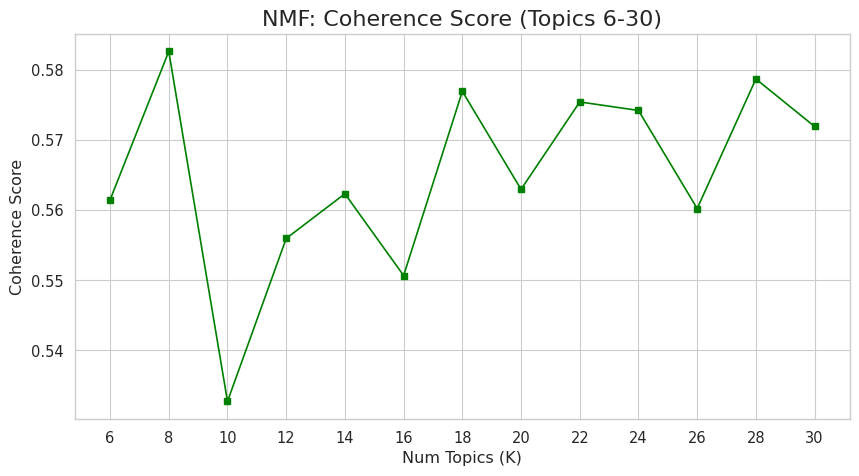

In [6]:
# ==============================================================================
# CELL 2: NMF TOPIC MODELING
# ==============================================================================
from gensim.models import Nmf, TfidfModel, CoherenceModel
from gensim import corpora
import pandas as pd
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import shutil
from tqdm.auto import tqdm
import warnings

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Suppress warnings
warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
INPUT_CSV = "/content/final_dataset_v3_preprocessed.csv"
OUTPUT_DIR_NMF = "/content/stage2_NMF"
ZIP_NAME_NMF = "/content/stage2_NMF_results"

if os.path.exists(OUTPUT_DIR_NMF):
    shutil.rmtree(OUTPUT_DIR_NMF)
os.makedirs(OUTPUT_DIR_NMF, exist_ok=True)

# File paths
OUTPUT_MODEL_NMF = os.path.join(OUTPUT_DIR_NMF, "nmf_model_best.gensim")
COHERENCE_PLOT_NMF = os.path.join(OUTPUT_DIR_NMF, "nmf_coherence_plot.png")
HTML_VIZ_NMF = os.path.join(OUTPUT_DIR_NMF, "topic_barchart.html")

# Grid Search Parameters
START_K = 6
LIMIT_K = 31
STEP_K  = 2

# ==============================================================================
# 1. DATA PREPARATION (TF-IDF)
# ==============================================================================
print("--- [NMF] Preparing TF-IDF Data ---")
if not os.path.exists(INPUT_CSV):
    print(f"❌ Error: File {INPUT_CSV} not found")
else:
    df = pd.read_csv(INPUT_CSV)
    df["tokens"] = df["processed_tokens"].apply(lambda x: json.loads(x) if isinstance(x, str) and x != "[]" else [])

    # Prepare corpus
    docs = df["tokens"].tolist()
    dictionary = corpora.Dictionary(docs)
    dictionary.filter_extremes(no_below=20, no_above=0.4)
    corpus_bow = [dictionary.doc2bow(text) for text in docs]

    # Create TF-IDF
    tfidf_model = TfidfModel(corpus_bow)
    corpus_tfidf = tfidf_model[corpus_bow]
    print(f"   Created TF-IDF Corpus. Size: {len(corpus_tfidf)}")

    # ==============================================================================
    # 2. FIND OPTIMAL NUMBER OF TOPICS (GRID SEARCH)
    # ==============================================================================
    print(f"\n--- [NMF] Finding optimal K (from {START_K} to {LIMIT_K-1}, step {STEP_K})... ---")
    nmf_scores = []
    nmf_models = []
    k_range = range(START_K, LIMIT_K, STEP_K)

    for k in tqdm(k_range, desc="Training NMF"):
        # Train NMF on TF-IDF
        model = Nmf(corpus=corpus_tfidf, id2word=dictionary, num_topics=k,
                    random_state=100, passes=10, kappa=1.0)
        # Calculate Coherence on original docs
        cm = CoherenceModel(model=model, texts=docs, dictionary=dictionary, coherence='c_v')
        nmf_scores.append(cm.get_coherence())
        nmf_models.append(model)

    # Plot Coherence Scores
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, nmf_scores, marker='s', color='green', linestyle='-')
    plt.title(f"NMF: Coherence Score (Topics {START_K}-{LIMIT_K-1})")
    plt.xlabel("Num Topics (K)")
    plt.ylabel("Coherence Score")
    plt.xticks(list(k_range))
    plt.grid(True)
    plt.savefig(COHERENCE_PLOT_NMF)
    print(f"   Saved plot to: {COHERENCE_PLOT_NMF}")

    # Select Best Model
    best_idx = np.argmax(nmf_scores)
    best_k_nmf = list(k_range)[best_idx]
    best_nmf = nmf_models[best_idx]
    print(f"\n🏆 BEST NMF RESULT: K={best_k_nmf} | Coherence={nmf_scores[best_idx]:.4f}")

    # ==============================================================================
    # 3. CREATE HTML VISUALIZATION (PLOTLY)
    # ==============================================================================
    print(f"⏳ Creating HTML visualization ({HTML_VIZ_NMF})...")

    top_n_words = 10
    topics_to_plot = best_k_nmf

    rows = (topics_to_plot + 3) // 4  # Calculate rows (4 columns per row)
    cols = min(topics_to_plot, 4)

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=[f"Topic {i+1}" for i in range(topics_to_plot)])

    for i in range(topics_to_plot):
        # Extract data from model
        topic_data = best_nmf.show_topic(i, topn=top_n_words)
        words = [w[0] for w in topic_data]
        weights = [w[1] for w in topic_data]

        row = i // 4 + 1
        col = i % 4 + 1
        # Add Horizontal Bar Chart
        fig.add_trace(go.Bar(x=weights, y=words, orientation='h', name=f"Topic {i+1}"), row=row, col=col)

    fig.update_layout(height=300*rows, width=1100, title_text="NMF Topic Word Scores", showlegend=False)
    fig.write_html(HTML_VIZ_NMF)
    print("   ✅ Created topic_barchart.html")

    # ==============================================================================
    # 4. CALCULATE DIVERSITY & SAVE MODEL
    # ==============================================================================
    top_n = 25
    all_words = []

    print("\n--- Topic List (NMF) ---")
    for i in range(best_k_nmf):
        words = best_nmf.show_topic(i, topn=top_n)
        all_words.extend([w for w, _ in words])
        topic_keywords_str = ", ".join([w for w, _ in words[:20]])
        print(f"Topic {i+1}: {topic_keywords_str[:80]}...")

    div = len(set(all_words)) / len(all_words)
    print(f"   ► Topic Diversity Score: {div:.4f}")

    # --- SAVE MODEL ---
    print(f"⏳ Saving Model...")
    best_nmf.save(OUTPUT_MODEL_NMF)

    # ==============================================================================
    # 5. ZIP RESULTS
    # ==============================================================================
    print(f"\n--- [ZIP] Compressing '{OUTPUT_DIR_NMF}'... ---")
    shutil.make_archive(ZIP_NAME_NMF, 'zip', OUTPUT_DIR_NMF)
    print(f"✅ Archive created successfully: {ZIP_NAME_NMF}.zip")

## BerTopic Model

In [7]:
!pip install -q bertopic dbscan umap-learn sentence_transformers gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 82.5 MB/s eta 0:00:00


--- [BERTopic] Preparing Data ---
   Docs: 61426 | Valid Vocab (Gensim): 4618

--- [BERTopic] Checking Embeddings ---
   Using device: CUDA


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Training BERTopic:   0%|          | 0/13 [00:00<?, ?it/s]

2026-01-07 15:40:25,011 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


   Saved plot to: /content/stage2_BERT/bert_coherence_plot.png

🏆 BEST BERTopic RESULT: K=28 | Coherence=0.3991

⚙️ Retraining Best Model (K=28)...


2026-01-07 15:41:39,407 - BERTopic - Dimensionality - Completed ✓
2026-01-07 15:41:39,410 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-01-07 15:49:01,301 - BERTopic - Cluster - Completed ✓
2026-01-07 15:49:01,302 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-01-07 15:49:02,547 - BERTopic - Representation - Completed ✓
2026-01-07 15:49:02,549 - BERTopic - Topic reduction - Reducing number of topics
2026-01-07 15:49:02,631 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-01-07 15:49:04,707 - BERTopic - Representation - Completed ✓
2026-01-07 15:49:04,719 - BERTopic - Topic reduction - Reduced number of topics from 266 to 28


⏳ Creating HTML Visualization...
   ✅ Created topic_barchart.html (Native Style)
   ✅ Created interactive_topics.html

--- Topic List (BERTopic) ---
Topic -1: bình_yên, người_yêu, quê_hương, thương_nhớ, ngọt_ngào, tình_yêu, mong_chờ, mộng_mơ, thế_giới, đớn_đau
Topic 0: người_yêu, mênh_mông, bình_yên, quê_hương, việt_nam, ngọt_ngào, tình_yêu, thế_giới, mong_chờ, thương_nhớ
Topic 1: vội_vàng, êm_đềm, hững_hờ, đắm_say, xa_rời, dại_khờ, thương_nhớ, đợi_chờ, yêu_thương, lá
Topic 2: ngọt_ngào, xuân, dịu_dàng, tưng_bừng, tình_yêu, người_yêu, yêu_thương, yêu_đời, thanh_bình, lứa_đôi
Topic 3: gió, hơi_thở, thổi, thì_thầm, xa_vời, hè, ngậm_ngùi, bầu_trời, bâng_khuâng, xa_xôi
Topic 4: cười_nụ, cười, đùa, vui, smile, ấm_áp, thì_thầm, ngọt_ngào, ước_mơ, yêu_thương
Topic 5: sợ, tình_cảm, đớn_đau, yêu_thương, vội_vàng, thương_hại, ngập_ngừng, ngại, tình_yêu, phiền
Topic 6: đông_lạnh, lạnh_lùng, tuyết, lạnh_giá, lạnh_cóng, ấm_áp, lạnh, lạnh_căm, đông, vội_vàng
Topic 7: mộng_mơ, ngọt_ngào, yêu_thương, 

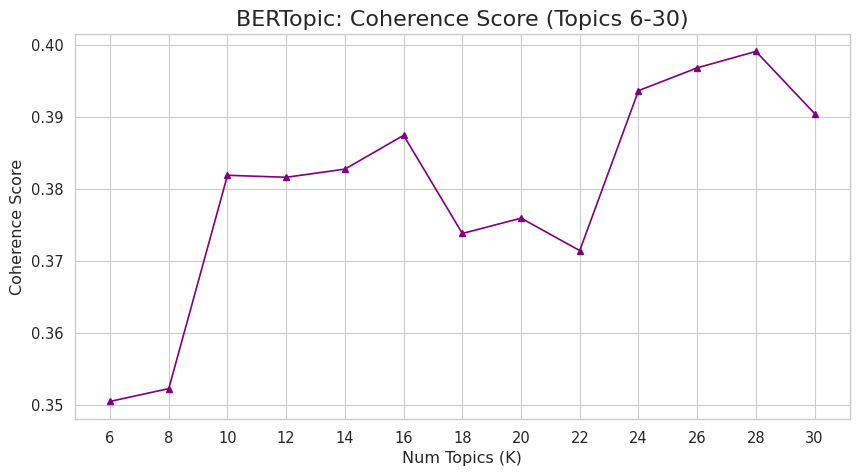

In [8]:
# ==============================================================================
# CELL 3: BERTOPIC MODELING
# ==============================================================================
import pandas as pd
import json
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
import torch
import contextlib

# Import BERTopic & Utils
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired  # <--- Added KeyBERT
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary
from umap import UMAP

# Suppress warnings
warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
INPUT_CSV = "/content/final_dataset_v3_preprocessed.csv"
OUTPUT_DIR_BERT = "/content/stage2_BERT"
ZIP_NAME_BERT = "/content/stage2_BERT_results"

if os.path.exists(OUTPUT_DIR_BERT):
    shutil.rmtree(OUTPUT_DIR_BERT)
os.makedirs(OUTPUT_DIR_BERT, exist_ok=True)

# File paths
OUTPUT_MODEL_BERT = os.path.join(OUTPUT_DIR_BERT, "best_bertopic_model")
COHERENCE_PLOT_BERT = os.path.join(OUTPUT_DIR_BERT, "bert_coherence_plot.png")
HTML_VIZ_BERT = os.path.join(OUTPUT_DIR_BERT, "topic_barchart.html")
CACHE_EMBEDDING_PATH = "/content/embeddings_cache.npy"

# Grid Search Parameters
START_K = 6
LIMIT_K = 31
STEP_K  = 2

# --- UTILITY FUNCTION ---
@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        yield

# ==============================================================================
# 1. DATA PREPARATION & EMBEDDINGS
# ==============================================================================
print("--- [BERTopic] Preparing Data ---")
if not os.path.exists(INPUT_CSV):
    print(f"❌ Error: File {INPUT_CSV} not found")
else:
    # 1. Read CSV
    df = pd.read_csv(INPUT_CSV)
    df["tokens"] = df["processed_tokens"].apply(lambda x: json.loads(x) if isinstance(x, str) and x != "[]" else [])

    # Prepare input
    docs_strings = [" ".join(tokens) for tokens in df["tokens"]]
    docs_tokens = df["tokens"].tolist()

    # 1. Create Dictionary (Gensim) - For Coherence Calculation
    dictionary = Dictionary(docs_tokens)
    dictionary.filter_extremes(no_below=40, no_above=0.4)
    print(f"   Docs: {len(docs_strings)} | Valid Vocab (Gensim): {len(dictionary)}")

    # 2. Compute / Load Embeddings
    print("\n--- [BERTopic] Checking Embeddings ---")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"   Using device: {device.upper()}")

    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
    embeddings = None
    need_compute = True

    if os.path.exists(CACHE_EMBEDDING_PATH):
        try:
            embeddings = np.load(CACHE_EMBEDDING_PATH)
            if len(embeddings) == len(docs_strings):
                print("   ✅ Loaded Embeddings from Cache!")
                need_compute = False
            else:
                print("   ⚠️ Cache size mismatch, recomputing...")
        except: pass

    if need_compute:
        print("⏳ Computing Embeddings (Batch Processing)...")
        embeddings = embedding_model.encode(docs_strings, show_progress_bar=True, batch_size=64)
        np.save(CACHE_EMBEDDING_PATH, embeddings)
        print(f"   ✅ Saved Embeddings to cache.")

    # ==============================================================================
    # 2. FIND OPTIMAL NUMBER OF TOPICS (GRID SEARCH)
    # ==============================================================================
    print(f"\n--- [BERTopic] Finding optimal K (from {START_K} to {LIMIT_K-1}, step {STEP_K})... ---")

    bert_scores = []

    # Configure Vectorizer (Keep same settings)
    vectorizer_model = CountVectorizer(tokenizer=lambda x: x.split(), ngram_range=(1, 1))

    # Configure Representation (KeyBERTInspired)
    representation_model = KeyBERTInspired()

    # Configure UMAP
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', low_memory=True, random_state=100)

    k_range = range(START_K, LIMIT_K, STEP_K)
    pbar = tqdm(k_range, desc="Training BERTopic")

    for k in pbar:
        try:
            # nr_topics=k: Force model to reduce to exactly k topics
            model = BERTopic(
                embedding_model=embedding_model,
                umap_model=umap_model,
                vectorizer_model=vectorizer_model,
                representation_model=representation_model, # <--- Apply KeyBERT
                nr_topics=k,
                verbose=False,
                calculate_probabilities=False
            )
            # Fit model
            topics, _ = model.fit_transform(docs_strings, embeddings=embeddings)

            # Calculate Coherence
            topics_info = model.get_topic_info()
            valid_topics = []
            for topic_id in topics_info['Topic']:
                if topic_id == -1: continue # Skip outlier topic -1
                words = [word for word, _ in model.get_topic(topic_id)]
                valid_topics.append(words)

            if not valid_topics: score = 0
            else:
                cm = CoherenceModel(topics=valid_topics, texts=docs_tokens, dictionary=dictionary, coherence='c_v')
                score = cm.get_coherence()

            bert_scores.append(score)
            pbar.set_postfix({'k': k, 'cv': f"{score:.3f}"})
        except:
            bert_scores.append(0)

    # Plot Coherence Scores
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, bert_scores, marker='^', color='purple', linestyle='-')
    plt.title(f"BERTopic: Coherence Score (Topics {START_K}-{LIMIT_K-1})")
    plt.xlabel("Num Topics (K)")
    plt.ylabel("Coherence Score")
    plt.xticks(list(k_range))
    plt.grid(True)
    plt.savefig(COHERENCE_PLOT_BERT)
    print(f"   Saved plot to: {COHERENCE_PLOT_BERT}")

    # Select Best Model
    best_idx = np.argmax(bert_scores)
    best_k_bert = list(k_range)[best_idx]
    print(f"\n🏆 BEST BERTopic RESULT: K={best_k_bert} | Coherence={bert_scores[best_idx]:.4f}")

    # ==============================================================================
    # 3. CREATE VISUALIZATION (NATIVE BERTOPIC)
    # ==============================================================================
    print(f"\n⚙️ Retraining Best Model (K={best_k_bert})...")

    # Re-initialize UMAP for final training to ensure consistency
    umap_model_final = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', low_memory=True, random_state=100)

    final_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model_final,
        vectorizer_model=vectorizer_model,
        representation_model=representation_model, # <--- Apply KeyBERT
        nr_topics=best_k_bert,
        verbose=True,
        calculate_probabilities=True
    )
    final_model.fit_transform(docs_strings, embeddings=embeddings)

    print(f"⏳ Creating HTML Visualization...")

    # --- 1. Bar Chart (Most Important) ---
    try:
        # top_n_topics: Max topics to show
        # n_words: Words per bar
        fig_bar = final_model.visualize_barchart(top_n_topics=best_k_bert, n_words=10)
        fig_bar.write_html(HTML_VIZ_BERT)
        print("   ✅ Created topic_barchart.html (Native Style)")
    except Exception as e:
        print(f"   ⚠️ Bar Chart Error: {e}")

    # --- 2. Intertopic Distance Map ---
    try:
        fig_dist = final_model.visualize_topics()
        fig_dist.write_html(os.path.join(OUTPUT_DIR_BERT, "interactive_topics.html"))
        print("   ✅ Created interactive_topics.html")
    except Exception as e:
        print(f"   ⚠️ Interactive Map Error: {e}")

    # ==============================================================================
    # 4. CALCULATE DIVERSITY & SAVE MODEL
    # ==============================================================================
    print("\n--- Topic List (BERTopic) ---")

    all_words = []
    topic_info = final_model.get_topic_info()

    # Iterate through topics to print and calculate diversity
    for index, row in topic_info.iterrows():
        tid = row['Topic']

        kw_list = [w[0] for w in final_model.get_topic(tid)][:25]
        all_words.extend(kw_list)

        kw_str = ", ".join(kw_list[:15])
        print(f"Topic {tid}: {kw_str}")

    div = len(set(all_words)) / len(all_words) if all_words else 0
    print(f"   ► Topic Diversity Score: {div:.4f}")

    # --- SAVE MODEL ---
    print(f"⏳ Saving Model...")
    final_model.save(OUTPUT_MODEL_BERT, serialization="safetensors")

    # ==============================================================================
    # 5. ZIP RESULTS
    # ==============================================================================
    print(f"\n--- [ZIP] Compressing '{OUTPUT_DIR_BERT}'... ---")
    shutil.make_archive(ZIP_NAME_BERT, 'zip', OUTPUT_DIR_BERT)
    print(f"✅ Archive created successfully: {ZIP_NAME_BERT}.zip")

## LSA Model

--- [LSA] Preparing Data ---
⏳ [LSA] Creating TF-IDF matrix...
   Vocabulary Size: 7716
   Matrix Shape: (61426, 7716)

--- [LSA] Finding optimal K (from 6 to 30, step 2)... ---


Training LSA:   0%|          | 0/13 [00:00<?, ?it/s]

   Saved plot to: /content/stage2_LSA/lsa_coherence_plot.png

🏆 BEST LSA RESULT: K=6 | Coherence=0.5651

⚙️ Retraining Best Model (K=6)...
⏳ Creating HTML visualization (/content/stage2_LSA/topic_barchart.html)...
   ✅ Created topic_barchart.html

--- Topic List (LSA) ---
Topic 1: mẹ, xuân, khóc, nước_mắt, lá, hạnh_phúc, thu, sầu, ôm, sông, cô_đơn, đông, người_yêu, trăng, vắng, lệ, hôn, quê, hứa, vội...
Topic 2: mẹ, cha, quê, ru, xuân, quê_hương, hiền, con_mẹ, cha_mẹ, gia_đình, lớn_khôn, mẹ_con, tết, khôn_lớn, việt_nam, làng, bé, cơm, tình_thương, nghèo...
Topic 3: xuân, hương, chim, tươi, tết, lá, mừng, quê, thu, nở, quê_hương, đẹp, sông, đông, cành, rộn_ràng, đào, thơm, sắc, giao_thừa...
Topic 4: thu, lá, sông, trăng, quê, biển, bến, sóng, ru, chim, sầu, hương, thuyền, quê_hương, đông, sương, vắng, rừng, thương_nhớ, tóc...
Topic 5: thu, lá, mẹ, đông, xuân, cô_đơn, người_yêu, vắng, lạnh, nước_mắt, hôn, hà_nội, rụng, khô, tuyết, giá_băng, buốt_giá, nhẹ_nhàng, ướt, cành...
Topic 6: khóc

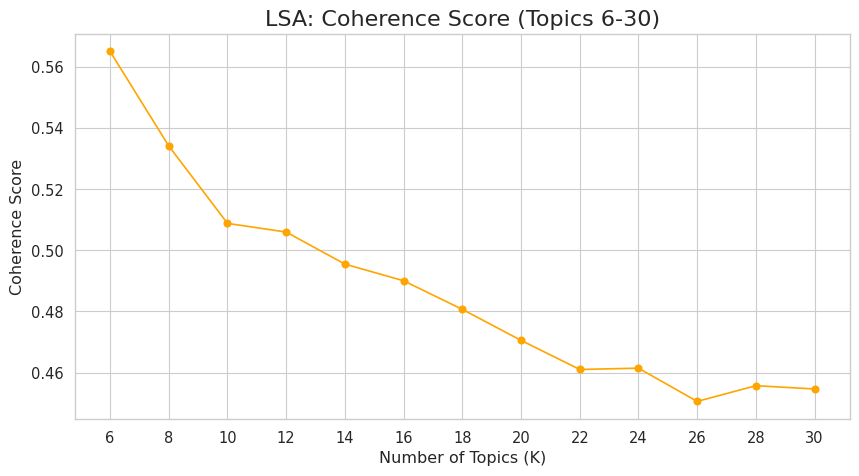

In [9]:
# ==============================================================================
# CELL 4: LSA TOPIC MODELING
# ==============================================================================
import pandas as pd
import json
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import joblib # Use joblib to save sklearn models
from tqdm.auto import tqdm
import warnings

# Sklearn for LSA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

# Gensim for Coherence
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# Visualization
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Suppress warnings
warnings.filterwarnings("ignore")

# --- CONFIGURATION ---
INPUT_CSV = "/content/final_dataset_v3_preprocessed.csv"
OUTPUT_DIR_LSA = "/content/stage2_LSA"
ZIP_NAME_LSA = "/content/stage2_LSA_results"

if os.path.exists(OUTPUT_DIR_LSA):
    shutil.rmtree(OUTPUT_DIR_LSA)
os.makedirs(OUTPUT_DIR_LSA, exist_ok=True)

# File paths
OUTPUT_MODEL_LSA = os.path.join(OUTPUT_DIR_LSA, "lsa_model_best.pkl")
OUTPUT_VECTORIZER = os.path.join(OUTPUT_DIR_LSA, "tfidf_vectorizer.pkl")
COHERENCE_PLOT_LSA = os.path.join(OUTPUT_DIR_LSA, "lsa_coherence_plot.png")
HTML_VIZ_LSA = os.path.join(OUTPUT_DIR_LSA, "topic_barchart.html")

# Grid Search Parameters
START_K = 6
LIMIT_K = 31
STEP_K  = 2

# ==============================================================================
# 1. DATA PREPARATION & TF-IDF
# ==============================================================================
print("--- [LSA] Preparing Data ---")
if not os.path.exists(INPUT_CSV):
    print(f"❌ Error: File {INPUT_CSV} not found")
else:
    # 1. Read CSV
    df = pd.read_csv(INPUT_CSV)
    df["tokens"] = df["processed_tokens"].apply(lambda x: json.loads(x) if isinstance(x, str) and x != "[]" else [])

    # Prepare input
    docs_strings = [" ".join(tokens) for tokens in df["tokens"]] # Input for Sklearn
    docs_tokens = df["tokens"].tolist()                        # Input for Gensim Coherence

    # 1. Create Dictionary (Gensim) - For Coherence Calculation
    dictionary = Dictionary(docs_tokens)
    dictionary.filter_extremes(no_below=10, no_above=0.15)

    # 2. Create TF-IDF Matrix (Sklearn) - For Model Training
    print("⏳ [LSA] Creating TF-IDF matrix...")
    vectorizer = TfidfVectorizer(min_df=10, max_df=0.15, use_idf=True)
    tfidf_matrix = vectorizer.fit_transform(docs_strings)
    feature_names = vectorizer.get_feature_names_out()

    print(f"   Vocabulary Size: {len(feature_names)}")
    print(f"   Matrix Shape: {tfidf_matrix.shape}")

    # ==============================================================================
    # 2. FIND OPTIMAL NUMBER OF TOPICS (GRID SEARCH)
    # ==============================================================================
    print(f"\n--- [LSA] Finding optimal K (from {START_K} to {LIMIT_K-1}, step {STEP_K})... ---")

    lsa_scores = []
    lsa_models = []
    k_range = range(START_K, LIMIT_K, STEP_K)

    for k in tqdm(k_range, desc="Training LSA"):
        # Train TruncatedSVD
        svd_model = TruncatedSVD(n_components=k, n_iter=10, random_state=100, algorithm='randomized')
        svd_model.fit(tfidf_matrix)

        # Extract Topics for Coherence Calculation
        topic_list = []
        for topic_idx, topic in enumerate(svd_model.components_):
            top_features_ind = topic.argsort()[:-11:-1]
            topic_words = [feature_names[i] for i in top_features_ind]
            topic_list.append(topic_words)

        # Calculate Coherence
        cm = CoherenceModel(topics=topic_list, texts=docs_tokens, dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()

        lsa_scores.append(score)
        lsa_models.append(svd_model)

    # Plot Coherence Scores
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, lsa_scores, marker='o', color='orange', linestyle='-')
    plt.title(f"LSA: Coherence Score (Topics {START_K}-{LIMIT_K-1})")
    plt.xlabel("Number of Topics (K)")
    plt.ylabel("Coherence Score")
    plt.xticks(list(k_range))
    plt.grid(True)
    plt.savefig(COHERENCE_PLOT_LSA)
    print(f"   Saved plot to: {COHERENCE_PLOT_LSA}")

    # Select Best Model
    best_idx = np.argmax(lsa_scores)
    best_k_lsa = list(k_range)[best_idx]
    best_lsa = lsa_models[best_idx]
    print(f"\n🏆 BEST LSA RESULT: K={best_k_lsa} | Coherence={lsa_scores[best_idx]:.4f}")

    # ==============================================================================
    # 3. CREATE HTML VISUALIZATION (PLOTLY)
    # ==============================================================================
    print(f"\n⚙️ Retraining Best Model (K={best_k_lsa})...")

    # Retrain final model
    best_lsa = TruncatedSVD(n_components=best_k_lsa, n_iter=20, random_state=100)
    best_lsa.fit(tfidf_matrix)

    print(f"⏳ Creating HTML visualization ({HTML_VIZ_LSA})...")

    top_n_words = 10
    topics_to_plot = best_k_lsa
    rows = (topics_to_plot + 3) // 4
    cols = min(topics_to_plot, 4)

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=[f"Topic {i+1}" for i in range(topics_to_plot)])

    for i in range(topics_to_plot):
        # Extract weights and words from SVD components
        topic_vector = best_lsa.components_[i]
        top_indices = topic_vector.argsort()[:-top_n_words-1:-1]

        words = [feature_names[idx] for idx in top_indices]
        weights = [topic_vector[idx] for idx in top_indices]

        row = i // 4 + 1
        col = i % 4 + 1
        fig.add_trace(go.Bar(x=weights, y=words, orientation='h', name=f"Topic {i+1}"), row=row, col=col)

    fig.update_layout(height=300*rows, width=1100, title_text="LSA Topic Word Scores", showlegend=False)
    fig.write_html(HTML_VIZ_LSA)
    print("   ✅ Created topic_barchart.html")

    # ==============================================================================
    # 4. CALCULATE DIVERSITY & SAVE MODEL
    # ==============================================================================
    print("\n--- Topic List (LSA) ---")

    all_words = []

    for i in range(best_k_lsa):
        topic_vector = best_lsa.components_[i]
        top_indices = topic_vector.argsort()[:-26:-1] # Top 25 words
        words = [feature_names[idx] for idx in top_indices]

        all_words.extend(words)
        print(f"Topic {i+1}: {', '.join(words[:20])}...")

    div = len(set(all_words)) / len(all_words) if all_words else 0
    print(f"   ► Topic Diversity Score: {div:.4f}")

    # --- SAVE MODEL ---
    print(f"⏳ Saving Model...")
    joblib.dump(best_lsa, OUTPUT_MODEL_LSA)
    joblib.dump(vectorizer, OUTPUT_VECTORIZER)

    # ==============================================================================
    # 5. ZIP RESULTS
    # ==============================================================================
    print(f"\n--- [ZIP] Compressing '{OUTPUT_DIR_LSA}'... ---")
    shutil.make_archive(ZIP_NAME_LSA, 'zip', OUTPUT_DIR_LSA)
    print(f"✅ Archive created successfully: {ZIP_NAME_LSA}.zip")

## Contextualized Topic Models (CTM)

In [10]:
!pip install -q contextualized-topic-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 75.3 MB/s eta 0:00:00


--- [CTM] Preparing Data ---
   Docs: 61426 | Valid Vocab (Final Clean): 5434
⏳ [CTM] Filtering BoW data...


Filtering:   0%|          | 0/61426 [00:00<?, ?it/s]


--- [CTM] Checking Embeddings ---
   Using device: CUDA
   ✅ Loaded Embeddings from Cache: /content/embeddings_cache.npy

📦 [CTM] Packaging training data...
   Vocab Size (CTM Cleaned): 5434

--- [CTM] Finding optimal K (from 6 to 30, step 2)... ---


Training CTM:   0%|          | 0/13 [00:00<?, ?it/s]

   Saved plot to: /content/stage2_CTM/ctm_coherence_plot.png

🏆 BEST CTM RESULT: K=20 | Coherence=0.6385

⚙️ Retraining Best Model (K=20)...


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

📊 Quick Stats:
Topic_Keywords
thư_tay, lưu_giữ, nhỏ_nhắn, váy_cưới, cười_nhạt       4706
quên, yêu_thương, xoá, vội, đau                       4258
tình_yêu, trái_tim, ngọt_ngào, hôn, dịu_dàng          3863
đổi_thay, dối_gian, lợi_danh, tay_trắng, giàu_sang    3816
người_yêu, người_tình, mong_chờ, nhớ_mong, xa_cách    3771
Name: count, dtype: int64

--- [ZIP] Compressing '/content/stage2_CTM'... ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

✅ Archive created successfully: /content/stage2_CTM_results.zip


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).



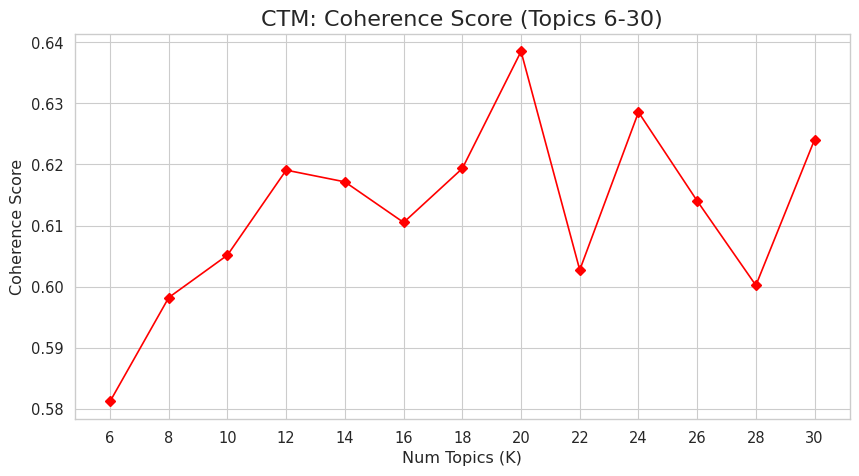

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning:

datetime.datetime.utcnow() is deprecated and scheduled for removal in a future v

In [11]:
# ==============================================================================
# CELL 5: CTM TOPIC MODELING
# ==============================================================================
import pandas as pd
import json
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
import torch
import contextlib
import logging
import random

# Visualization libraries
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# CTM & Gensim
from contextualized_topic_models.models.ctm import CombinedTM
from contextualized_topic_models.utils.data_preparation import TopicModelDataPreparation
from sentence_transformers import SentenceTransformer
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# Suppress warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("contextualized_topic_models").setLevel(logging.ERROR)

# --- RANDOM SEED FUNCTION ---
def set_seed(seed_value=42):
    """Set seed for reproducibility."""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed_value)
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# --- CONFIGURATION ---
INPUT_CSV = "/content/final_dataset_v3_preprocessed.csv"
OUTPUT_DIR_CTM = "/content/stage2_CTM"
ZIP_NAME_CTM = "/content/stage2_CTM_results"
CACHE_EMBEDDING_PATH = '/content/embeddings_cache.npy'

# Output path for tagged dataset
OUTPUT_TAGGED_CSV = "/content/final_dataset_with_topics.csv"

if os.path.exists(OUTPUT_DIR_CTM):
    shutil.rmtree(OUTPUT_DIR_CTM)
os.makedirs(OUTPUT_DIR_CTM, exist_ok=True)

# File paths
COHERENCE_PLOT_CTM = os.path.join(OUTPUT_DIR_CTM, "ctm_coherence_plot.png")
HTML_VIZ_CTM = os.path.join(OUTPUT_DIR_CTM, "topic_barchart.html")

# Grid Search Parameters
START_K = 6
LIMIT_K = 31
STEP_K  = 2

# --- UTILITY FUNCTION ---
@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as f, contextlib.redirect_stdout(f), contextlib.redirect_stderr(f):
        yield

# ==============================================================================
# 1. DATA PREPARATION & EMBEDDINGS
# ==============================================================================
set_seed(42)

print("--- [CTM] Preparing Data ---")
if not os.path.exists(INPUT_CSV):
    print(f"❌ Error: File {INPUT_CSV} not found")
else:
    # 1. Read CSV
    df = pd.read_csv(INPUT_CSV)
    df["tokens"] = df["processed_tokens"].apply(lambda x: json.loads(x) if isinstance(x, str) and x != "[]" else [])

    docs_tokens = df["tokens"].tolist()

    # 2. Create Dictionary & Filter Extremes
    dictionary = Dictionary(docs_tokens)
    # Filter: Keep words appearing in >30 docs and <50% of docs
    dictionary.filter_extremes(no_below=30, no_above=0.5)
    valid_vocab = set(dictionary.token2id.keys())

    print(f"   Docs: {len(docs_tokens)} | Valid Vocab (Final Clean): {len(valid_vocab)}")

    # 3. Create Input for CTM (Filter BoW)
    print("⏳ [CTM] Filtering BoW data...")
    docs_contextual = [" ".join(tokens) for tokens in docs_tokens]

    docs_bow_filtered = []
    for tokens in tqdm(docs_tokens, desc="Filtering"):
        filtered_tokens = [w for w in tokens if w in valid_vocab]
        docs_bow_filtered.append(" ".join(filtered_tokens))

    # 4. Compute / Load Embeddings
    print("\n--- [CTM] Checking Embeddings ---")
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"   Using device: {device.upper()}")

    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2", device=device)
    embeddings = None

    # Check for cached embeddings
    if os.path.exists(CACHE_EMBEDDING_PATH):
        try:
            embeddings = np.load(CACHE_EMBEDDING_PATH)
            if len(embeddings) == len(docs_contextual):
                print(f"   ✅ Loaded Embeddings from Cache: {CACHE_EMBEDDING_PATH}")
            else:
                print("   ⚠️ Cache size mismatch, recomputing...")
                embeddings = embedding_model.encode(docs_contextual, show_progress_bar=True, batch_size=64)
                np.save(CACHE_EMBEDDING_PATH, embeddings)
        except:
            print("   ⚠️ Error reading cache, recomputing...")
            embeddings = embedding_model.encode(docs_contextual, show_progress_bar=True, batch_size=64)
            np.save(CACHE_EMBEDDING_PATH, embeddings)
    else:
        print("⏳ Cache not found. Computing new Embeddings...")
        embeddings = embedding_model.encode(docs_contextual, show_progress_bar=True, batch_size=64)
        np.save(CACHE_EMBEDDING_PATH, embeddings)
        print(f"   ✅ Saved Embeddings to: {CACHE_EMBEDDING_PATH}")

    # 5. Prepare Training Dataset
    print("\n📦 [CTM] Packaging training data...")
    tp = TopicModelDataPreparation("paraphrase-multilingual-MiniLM-L12-v2")
    with suppress_output():
        training_dataset = tp.fit(text_for_contextual=docs_contextual, text_for_bow=docs_bow_filtered, custom_embeddings=embeddings)
    print(f"   Vocab Size (CTM Cleaned): {len(tp.vocab)}")

    # ==============================================================================
    # 2. FIND OPTIMAL NUMBER OF TOPICS (GRID SEARCH)
    # ==============================================================================
    print(f"\n--- [CTM] Finding optimal K (from {START_K} to {LIMIT_K-1}, step {STEP_K})... ---")

    ctm_scores = []
    k_range = range(START_K, LIMIT_K, STEP_K)
    pbar = tqdm(k_range, desc="Training CTM")

    for k in pbar:
        try:
            # Fix seed before each training run
            set_seed(42)

            with suppress_output():
                ctm = CombinedTM(
                    bow_size=len(tp.vocab), contextual_size=embeddings.shape[1], n_components=k,
                    num_epochs=10, batch_size=200, hidden_sizes=(100,), activation='softplus',
                    dropout=0.2, lr=0.002, momentum=0.99, solver='adam', reduce_on_plateau=True
                )
                ctm.fit(training_dataset)

            # Calculate Coherence
            topics = ctm.get_topic_lists(10)
            valid_topics = [[w for w in t if w in dictionary.token2id] for t in topics]
            valid_topics = [t for t in valid_topics if len(t) > 0]

            if not valid_topics: score = 0
            else:
                cm = CoherenceModel(topics=valid_topics, texts=docs_tokens, dictionary=dictionary, coherence='c_v')
                score = cm.get_coherence()

            ctm_scores.append(score)
            pbar.set_postfix({'k': k, 'cv': f"{score:.3f}"})
        except Exception as e:
            print(f"Error at k={k}: {e}")
            ctm_scores.append(0)

    # Plot Coherence Scores
    plt.figure(figsize=(10, 5))
    plt.plot(k_range, ctm_scores, marker='D', color='red', linestyle='-')
    plt.title(f"CTM: Coherence Score (Topics {START_K}-{LIMIT_K-1})")
    plt.xlabel("Num Topics (K)")
    plt.ylabel("Coherence Score")
    plt.xticks(list(k_range))
    plt.grid(True)
    plt.savefig(COHERENCE_PLOT_CTM)
    print(f"   Saved plot to: {COHERENCE_PLOT_CTM}")

    # Select Best Model
    best_idx = np.argmax(ctm_scores)
    best_k_ctm = list(k_range)[best_idx]
    print(f"\n🏆 BEST CTM RESULT: K={best_k_ctm} | Coherence={ctm_scores[best_idx]:.4f}")

    # ==============================================================================
    # 3. CREATE HTML VISUALIZATION
    # ==============================================================================
    print(f"\n⚙️ Retraining Best Model (K={best_k_ctm})...")

    # Fix seed again
    set_seed(42)

    best_ctm = CombinedTM(
        bow_size=len(tp.vocab), contextual_size=embeddings.shape[1], n_components=best_k_ctm,
        num_epochs=50, batch_size=200, hidden_sizes=(100,), activation='softplus',
        dropout=0.2, lr=0.002, momentum=0.99, solver='adam', reduce_on_plateau=True
    )
    best_ctm.fit(training_dataset)

    print(f"⏳ Creating HTML visualization ({HTML_VIZ_CTM})...")
    topic_word_matrix = best_ctm.get_topic_word_matrix()
    vocab = tp.vocab

    top_n_words = 10
    topics_to_plot = best_k_ctm
    rows = (topics_to_plot + 3) // 4
    cols = min(topics_to_plot, 4)

    fig = make_subplots(rows=rows, cols=cols, subplot_titles=[f"Topic {i+1}" for i in range(topics_to_plot)])

    for i in range(topics_to_plot):
        top_indices = np.argsort(topic_word_matrix[i])[-top_n_words:]
        words = [vocab[idx] for idx in top_indices]
        weights = [topic_word_matrix[i][idx] for idx in top_indices]

        row = i // 4 + 1
        col = i % 4 + 1
        fig.add_trace(go.Bar(x=weights, y=words, orientation='h', name=f"Topic {i+1}"), row=row, col=col)

    fig.update_layout(height=300*rows, width=1100, title_text="CTM Topic Word Scores", showlegend=False)
    fig.write_html(HTML_VIZ_CTM)
    print("   ✅ Created topic_barchart.html")

    # ==============================================================================
    # 4. CALCULATE DIVERSITY & SAVE MODEL
    # ==============================================================================
    print("\n--- Topic List (CTM) ---")
    topics_output = best_ctm.get_topic_lists(25)
    all_words = []

    for i, words in enumerate(topics_output):
        all_words.extend(words)
        print(f"Topic {i+1}: {', '.join(words[:25])}")

    div = len(set(all_words)) / len(all_words) if all_words else 0
    print(f"   ► Topic Diversity Score: {div:.4f}")

    # --- SAVE MODEL ---
    print(f"⏳ Saving Model...")
    with suppress_output():
        best_ctm.save(models_dir=OUTPUT_DIR_CTM)

    # ==============================================================================
    # 5. ASSIGN TOPICS TO DATA (INFERENCE)
    # ==============================================================================
    print(f"\n🔮 Assigning Topics to all {len(df)} songs...")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        thetas = best_ctm.get_thetas(training_dataset)

    # Find dominant topic
    dominant_topic = np.argmax(thetas, axis=1)
    confidence = np.max(thetas, axis=1)

    # Map ID -> Keywords
    topic_keywords_map = {}
    topics_list = best_ctm.get_topic_lists(5)
    for idx, words in enumerate(topics_list):
        topic_keywords_map[idx] = ", ".join(words)

    # Assign to DataFrame
    df['Topic_ID'] = dominant_topic
    df['Confidence_Score'] = confidence
    df['Topic_Keywords'] = df['Topic_ID'].map(topic_keywords_map)

    # Save to CSV
    print(f"💾 Saving result file: {OUTPUT_TAGGED_CSV}")
    df.to_csv(OUTPUT_TAGGED_CSV, index=False)

    print("📊 Quick Stats:")
    print(df['Topic_Keywords'].value_counts().head(5))

    # ==============================================================================
    # 6. ZIP RESULTS
    # ==============================================================================
    print(f"\n--- [ZIP] Compressing '{OUTPUT_DIR_CTM}'... ---")
    shutil.make_archive(ZIP_NAME_CTM, 'zip', OUTPUT_DIR_CTM)
    print(f"✅ Archive created successfully: {ZIP_NAME_CTM}.zip")

# Quantitative Historical Analysis

--- LOADING DATA ---
✅ Total songs: 61426

SUMMARY TABLE OF 20 TOPICS
 ID Label                               Song Count Keywords                                             
 0                Letting Go & Healing 3178                  nước_mắt, hạnh_phúc, đau, buông, cố_gắng...
 1   Lyrical Bolero & Melancholic Fate 3400                                sầu, lệ, duyên, nàng, buồn...
 2           War, History & The Nation 2474                        việt_nam, quê_hương, máu, dân, núi...
 3     Tet Atmosphere & Spring Reunion 2940                                xuân, vui, tươi, hoa, mừng...
 4               Betrayal & Heartbreak 4258                           quên, yêu_thương, xoá, vội, đau...
 5          Nature's Beauty & Homeland 1722                          hoa, hương, gió, sông, quê_hương...
 6  Romantic Emotions & Season of Love 2011                          nắng, gió, cười, yêu_thương, mây...
 7        Southern Folk & Mekong Delta 2957                             thương, sông, quê,

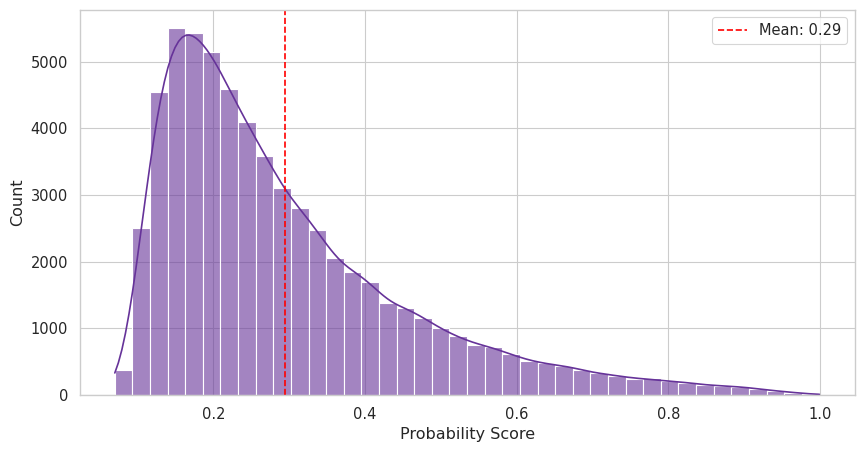


[Chart 2] Distinctiveness of Each Music Genre (Boxplot)...


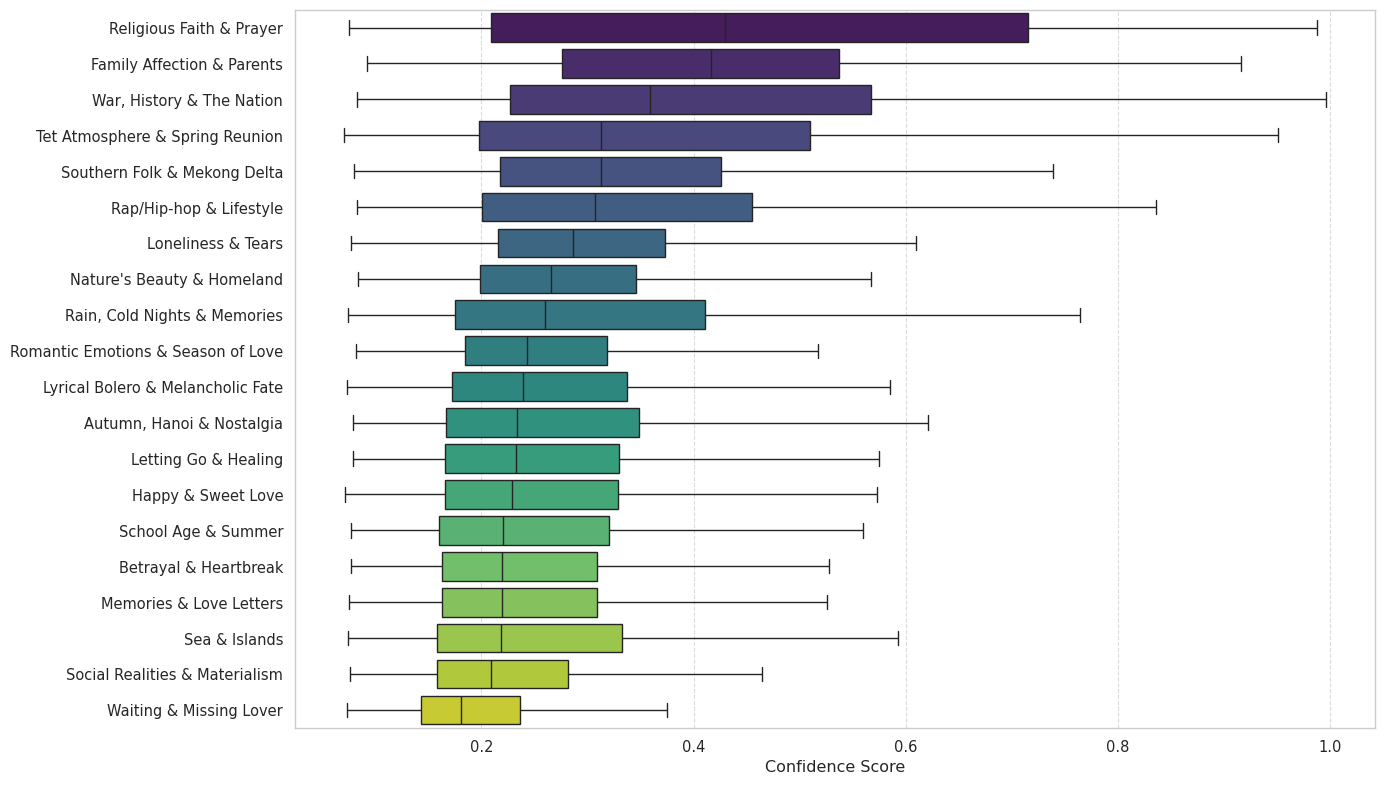


[Chart 3] Top Composers ...


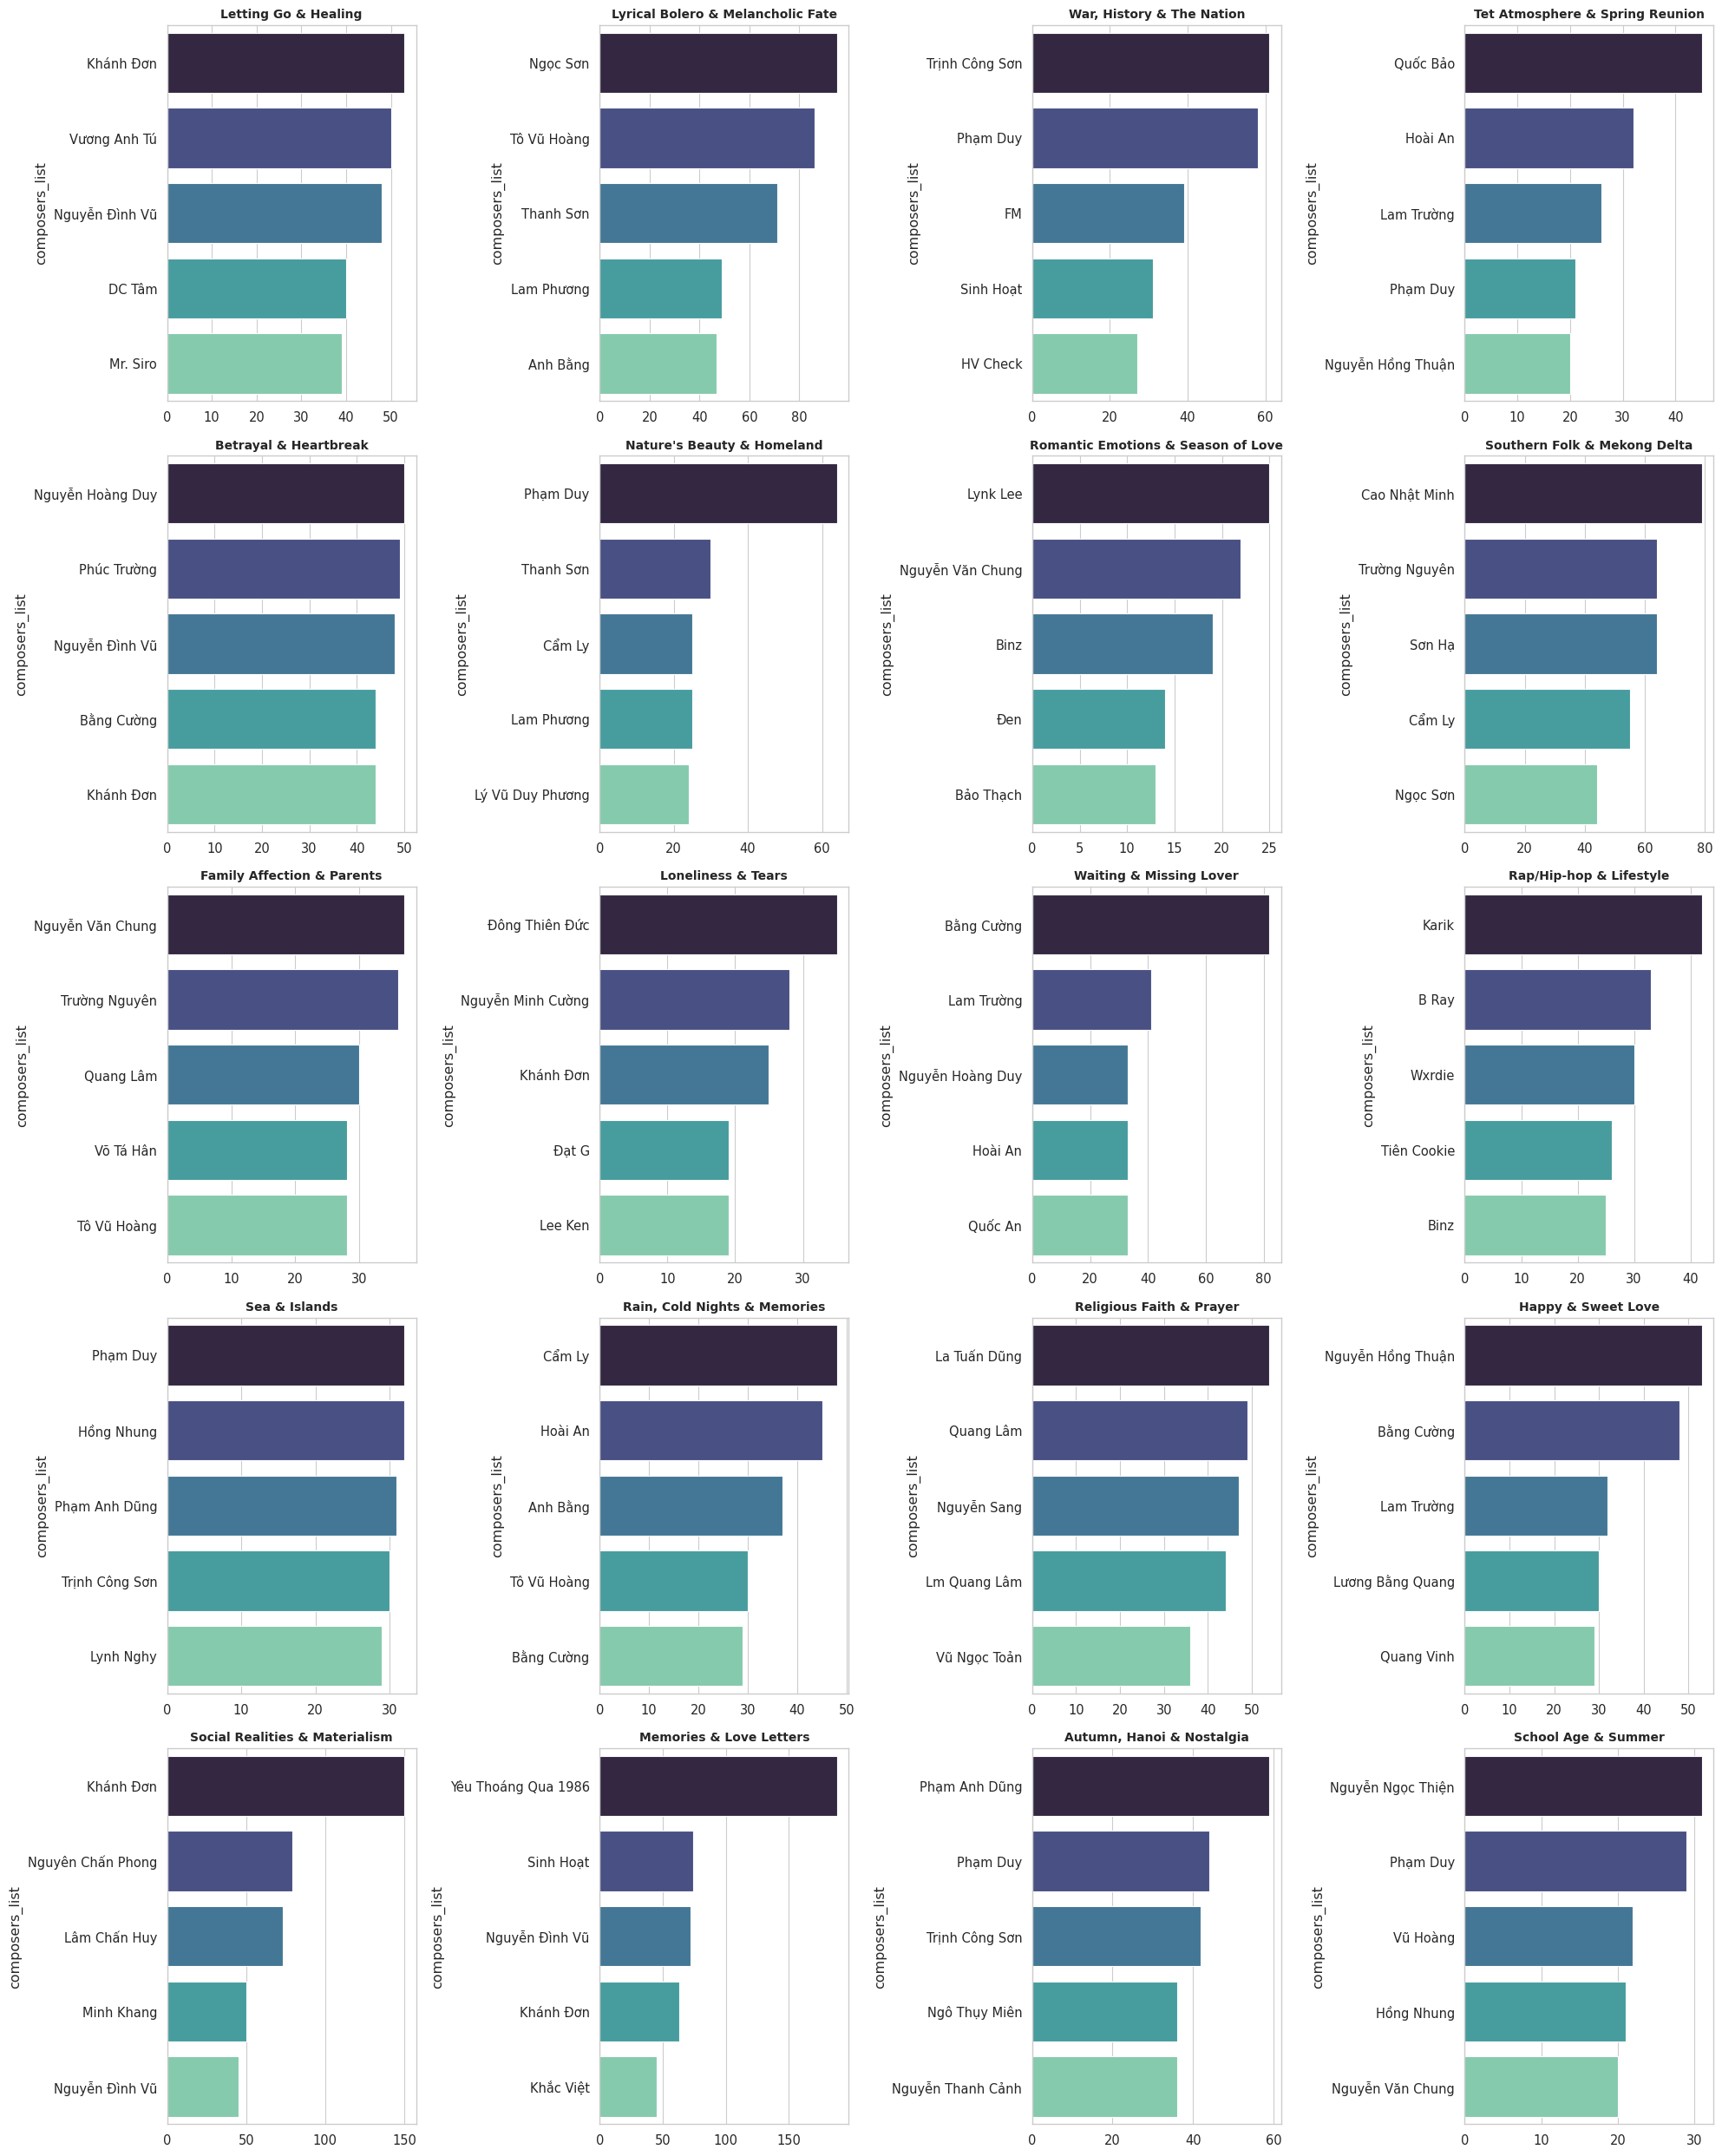


--- FILTERING DATA FOR TREND CHARTS ---

[Chart 4] Evolution of Music Structure (Macro Groups)...


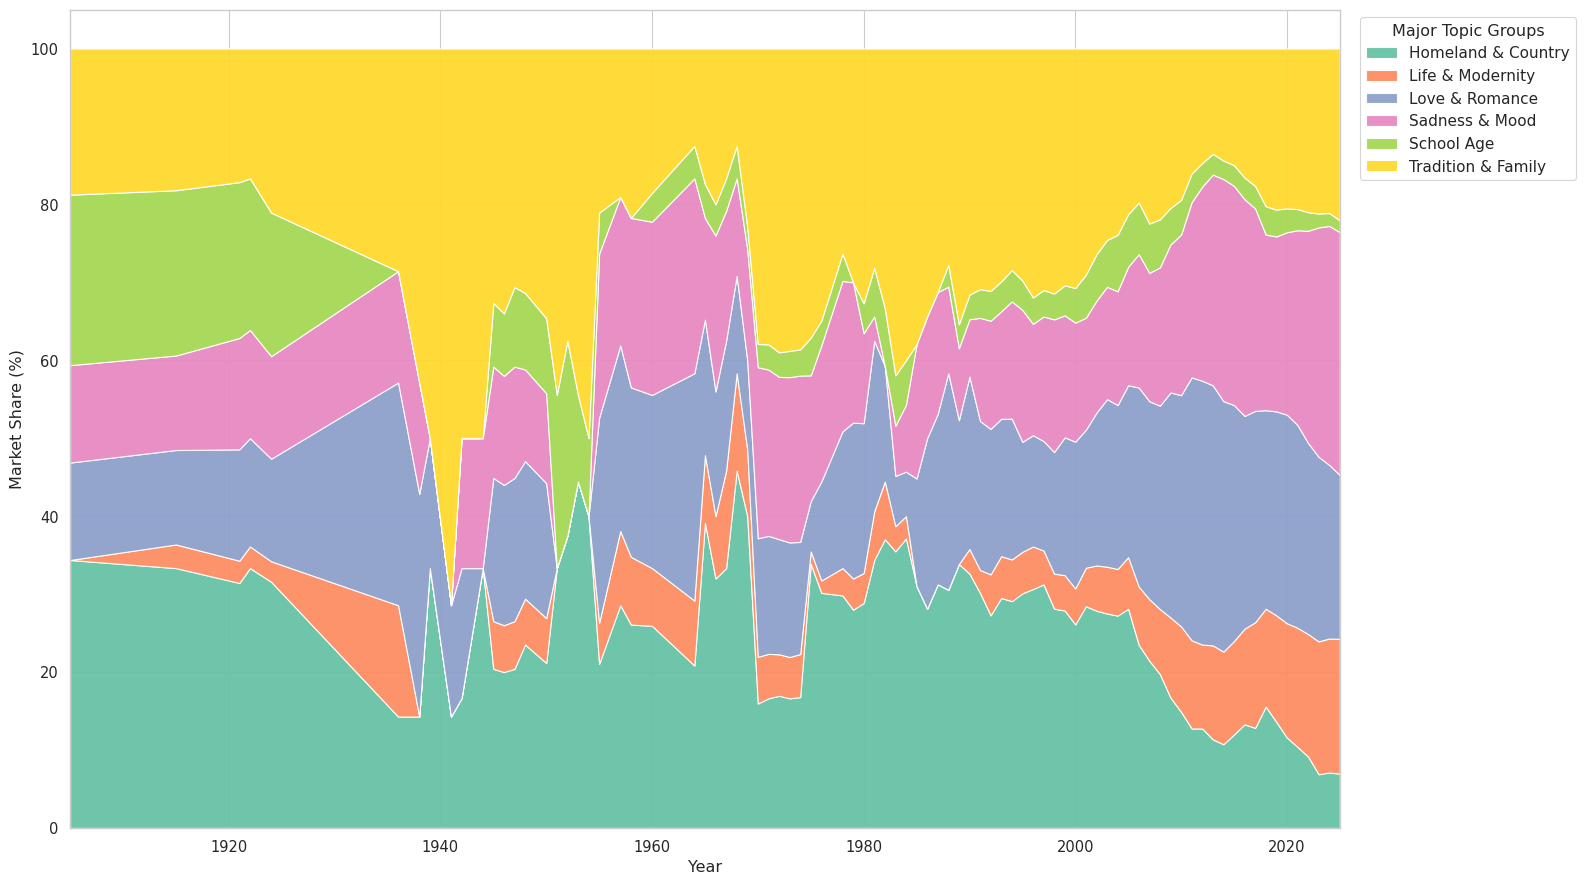


[Chart 5] Detailed Trends ...


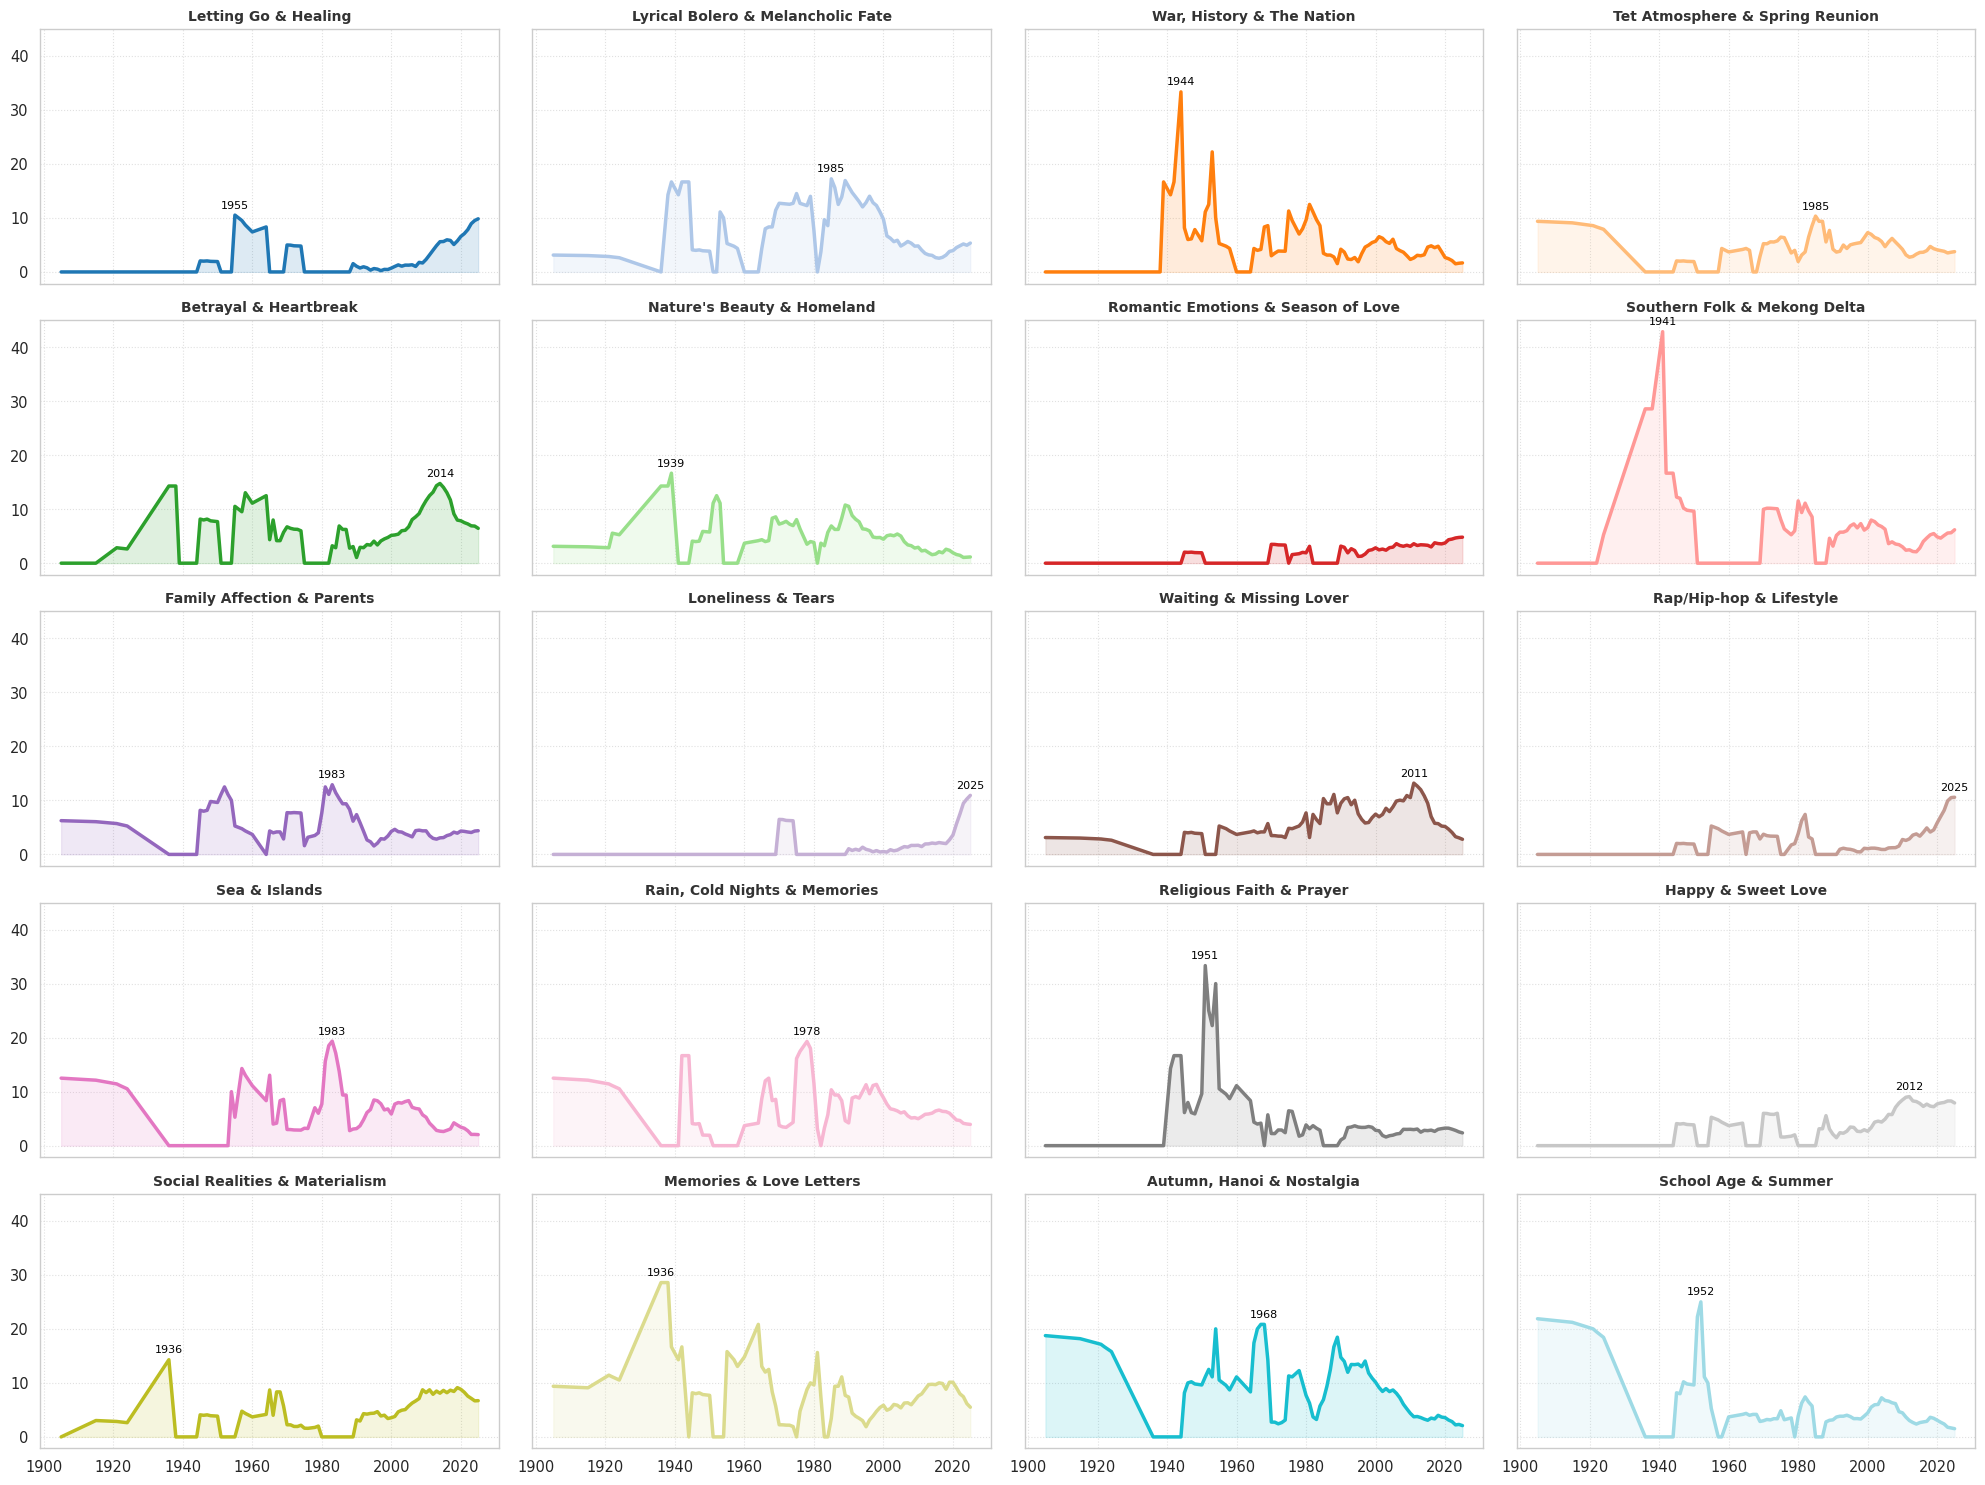


✅ Analysis and Visualization Completed!


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import ast
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style("whitegrid")

INPUT_CSV = "/content/final_dataset_with_topics.csv"

# Detailed Mapping of 20 Topics
topic_labels = {
    0:  'Letting Go & Healing',             # Sự Buông Bỏ & Chữa Lành
    1:  'Lyrical Bolero & Melancholic Fate',# Nhạc Trữ Tình & Sầu Duyên Kiếp
    2:  'War, History & The Nation',        # Chiến Tranh, Lịch sử & Đất Nước
    3:  'Tet Atmosphere & Spring Reunion',  # Không Khí Tết & Xuân Sum Vầy
    4:  'Betrayal & Heartbreak',            # Sự Phản Bội & Tan Vỡ
    5:  'Nature\'s Beauty & Homeland',      # Vẻ Đẹp Thiên Nhiên & Quê Hương
    6:  'Romantic Emotions & Season of Love',# Cảm Xúc Lãng Mạn & Mùa Yêu
    7:  'Southern Folk & Mekong Delta',     # Dân Ca Nam Bộ & Miền Tây
    8:  'Family Affection & Parents',       # Tình Cảm Gia Đình & Cha Mẹ
    9:  'Loneliness & Tears',               # Nỗi Buồn Cô Đơn & Nước Mắt
    10: 'Waiting & Missing Lover',          # Sự Chờ Đợi & Nhớ Người Yêu
    11: 'Rap/Hip-hop & Lifestyle',          # Rap/Hip-hop & Phong Cách Sống
    12: 'Sea & Islands',                    # Biển Đảo & Tiếng Sóng
    13: 'Rain, Cold Nights & Memories',     # Cơn Mưa, Đêm Lạnh & Ký Ức
    14: 'Religious Faith & Prayer',         # Đức Tin Tôn Giáo & Cầu Nguyện
    15: 'Happy & Sweet Love',               # Tình Yêu Hạnh Phúc & Ngọt Ngào
    16: 'Social Realities & Materialism',   # Thế Thái Nhân Tình & Vật Chất
    17: 'Memories & Love Letters',          # Tự Sự, Ký Ức & Thư Tình
    18: 'Autumn, Hanoi & Nostalgia',        # Mùa Thu, Hà Nội & Hoài Niệm
    19: 'School Age & Summer'               # Tuổi Học Trò & Mùa Hè
}

# Group 20 topics into 6 macro groups
topic_groups_map = {
    6: 'Love & Romance', 10: 'Love & Romance', 15: 'Love & Romance', 17: 'Love & Romance',
    0: 'Sadness & Mood', 4: 'Sadness & Mood', 9: 'Sadness & Mood', 13: 'Sadness & Mood',
    2: 'Homeland & Country', 5: 'Homeland & Country', 12: 'Homeland & Country', 18: 'Homeland & Country',
    1: 'Tradition & Family', 3: 'Tradition & Family', 7: 'Tradition & Family', 8: 'Tradition & Family', 14: 'Tradition & Family',
    11: 'Life & Modernity', 16: 'Life & Modernity',
    19: 'School Age'
}

# ============================= 1. LOAD & PROCESS DATA =============================
print("--- LOADING DATA ---")
if not os.path.exists(INPUT_CSV):
    print(f"ERROR: File {INPUT_CSV} not found")
    exit()

df = pd.read_csv(INPUT_CSV)

# Normalize column names
rename_map = {'Topic_ID': 'dominant_topic', 'Confidence_Score': 'topic_prob', 'Topic_Keywords': 'topic_keywords', 'song_name': 'title'}
df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}, inplace=True)

# Map Labels & Groups
df['topic_label'] = df['dominant_topic'].map(topic_labels)
df['macro_group'] = df['dominant_topic'].map(topic_groups_map)

# Process composers
def parse_list_col(x):
    try:
        if isinstance(x, str) and x.startswith('['): return ast.literal_eval(x)
        return []
    except: return []
if 'composers' in df.columns: df['composers_list'] = df['composers'].apply(parse_list_col)

total_songs = len(df)
print(f"✅ Total songs: {total_songs}")

# ============================= 2. SUMMARY TABLE =============================
print("\n" + "="*80)
print(f"SUMMARY TABLE OF {len(topic_labels)} TOPICS")
print("="*80)

summary_data = []
for topic_id in sorted(topic_labels.keys()):
    subset = df[df['dominant_topic'] == topic_id]
    if subset.empty: continue
    keywords = subset['topic_keywords'].iloc[0] if 'topic_keywords' in subset.columns else "N/A"
    summary_data.append({
        'ID': topic_id, 'Label': topic_labels[topic_id], 'Song Count': len(subset),
        'Keywords': keywords[:60] + "..."
    })

df_summ = pd.DataFrame(summary_data)
pd.set_option('display.max_colwidth', 100)
print(df_summ.to_string(index=False, justify='left'))

# ============================= 3. NON-TEMPORAL CHARTS =============================

# --- CHART 1: CONFIDENCE SCORE DISTRIBUTION ---
print("\n[Chart 1] Evaluating Model Health (Confidence Distribution)...")
plt.figure(figsize=(10, 5))
sns.histplot(df['topic_prob'], bins=40, kde=True, color='rebeccapurple', alpha=0.6)
plt.axvline(df['topic_prob'].mean(), color='red', linestyle='--', label=f"Mean: {df['topic_prob'].mean():.2f}")
plt.xlabel('Probability Score')
plt.legend()
plt.show()

# --- CHART 2: BOXPLOT ---
print("\n[Chart 2] Distinctiveness of Each Music Genre (Boxplot)...")
plt.figure(figsize=(14, 8))
order = df.groupby('topic_label')['topic_prob'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='topic_prob', y='topic_label', order=order, palette="viridis", showfliers=False)
plt.xlabel('Confidence Score')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# --- CHART 3: TOP COMPOSERS ---
if 'composers' in df.columns:
    print("\n[Chart 3] Top Composers ...")
    df_exploded = df.explode('composers_list')
    df_exploded = df_exploded[df_exploded['composers_list'].notna() & (df_exploded['composers_list'] != '')]

    all_topics = sorted(topic_labels.keys())

    # 4 columns layout for 20 plots (5 rows)
    cols = 4
    rows = (len(all_topics) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
    axes = axes.flatten()

    for i, tid in enumerate(all_topics):
        ax = axes[i]
        label = topic_labels[tid]
        subset = df_exploded[df_exploded['dominant_topic'] == tid]
        if not subset.empty:
            top_composers = subset['composers_list'].value_counts().head(5)
            if not top_composers.empty:
                sns.barplot(x=top_composers.values, y=top_composers.index, ax=ax, palette="mako", hue=top_composers.index, legend=False)
                ax.set_title(label, fontweight='bold', fontsize=10)
                ax.set_xlabel("")
            else: ax.text(0.5, 0.5, "No Data", ha='center')
        else: ax.set_visible(False)

    for j in range(i + 1, len(axes)): axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

# ============================= 4. FILTER TIME DATA =============================
print("\n--- FILTERING DATA FOR TREND CHARTS ---")
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df_viz = df.dropna(subset=['year'])
df_viz = df_viz[(df_viz['year'] >= 1900) & (df_viz['year'] <= 2025)]
df_viz['year'] = df_viz['year'].astype(int)

# ============================= 5. TEMPORAL TREND CHARTS =============================

# --- CHART 4: GROUPED STACKED AREA ---
print("\n[Chart 4] Evolution of Music Structure (Macro Groups)...")
pivot_group = pd.crosstab(df_viz['year'], df_viz['macro_group'])
pivot_group_smooth = pivot_group.rolling(window=5, min_periods=1).mean()
pivot_group_pct = pivot_group_smooth.div(pivot_group_smooth.sum(axis=1), axis=0) * 100
group_palette = sns.color_palette("Set2", n_colors=6)

plt.figure(figsize=(16, 9))
plt.stackplot(pivot_group_pct.index, pivot_group_pct.T, labels=pivot_group_pct.columns, colors=group_palette, alpha=0.95, edgecolor='white')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), title="Major Topic Groups", fontsize='11')
plt.ylabel('Market Share (%)')
plt.xlabel('Year')
plt.xlim(int(df_viz['year'].min()), int(df_viz['year'].max()))
plt.tight_layout()
plt.show()

# --- CHART 5: SMALL MULTIPLES ---
print("\n[Chart 5] Detailed Trends ...")
pivot_detail = pd.crosstab(df_viz['year'], df_viz['topic_label'])
pivot_detail_smooth = pivot_detail.rolling(window=5, min_periods=1).mean()
pivot_detail_pct = pivot_detail_smooth.div(pivot_detail_smooth.sum(axis=1), axis=0) * 100

topics = [topic_labels[i] for i in sorted(topic_labels.keys())]

# 4 columns layout for 20 plots
cols = 4
rows = (len(topics) + cols - 1) // cols
main_palette = sns.color_palette("tab20", n_colors=20)

fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, topic in enumerate(topics):
    ax = axes[i]
    if topic in pivot_detail_pct.columns:
        original_id = [k for k, v in topic_labels.items() if v == topic][0]
        color = main_palette[original_id % 20]

        ax.plot(pivot_detail_pct.index, pivot_detail_pct[topic], linewidth=2.5, color=color)
        ax.fill_between(pivot_detail_pct.index, pivot_detail_pct[topic], alpha=0.15, color=color)

        max_val = pivot_detail_pct[topic].max()
        max_year = pivot_detail_pct[topic].idxmax()
        if max_val > 5:
             ax.annotate(f'{int(max_year)}', xy=(max_year, max_val), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=8, color='black')

        ax.set_title(topic, fontsize=10, fontweight='bold', color='#333333')
        ax.grid(True, linestyle=':', alpha=0.6)
    else: ax.set_visible(False)

for j in range(i + 1, len(axes)): axes[j].set_visible(False)
plt.tight_layout()
plt.show()

print("\n✅ Analysis and Visualization Completed!")